In [ ]:
# Plot frequencies by region with varying dates timeframes

## Geofigure 1 - Global Map

Global 4 panel figure: 
- October 2023 to May 2024
- October 2024 to May 2025
- October 2025 to May 2026
- panel D all time in the dataset (filter for latest and easliest sequence in the dataset)

## Geofigure 2 
Region Frequcny Graph over time 
- Region 1
- Region 2
- Region 3
- Region 4
- Region 5

Add a red verticle line indicating the first detection of C.3.1 

Saved → ../figures/map_subclades_global_country.png


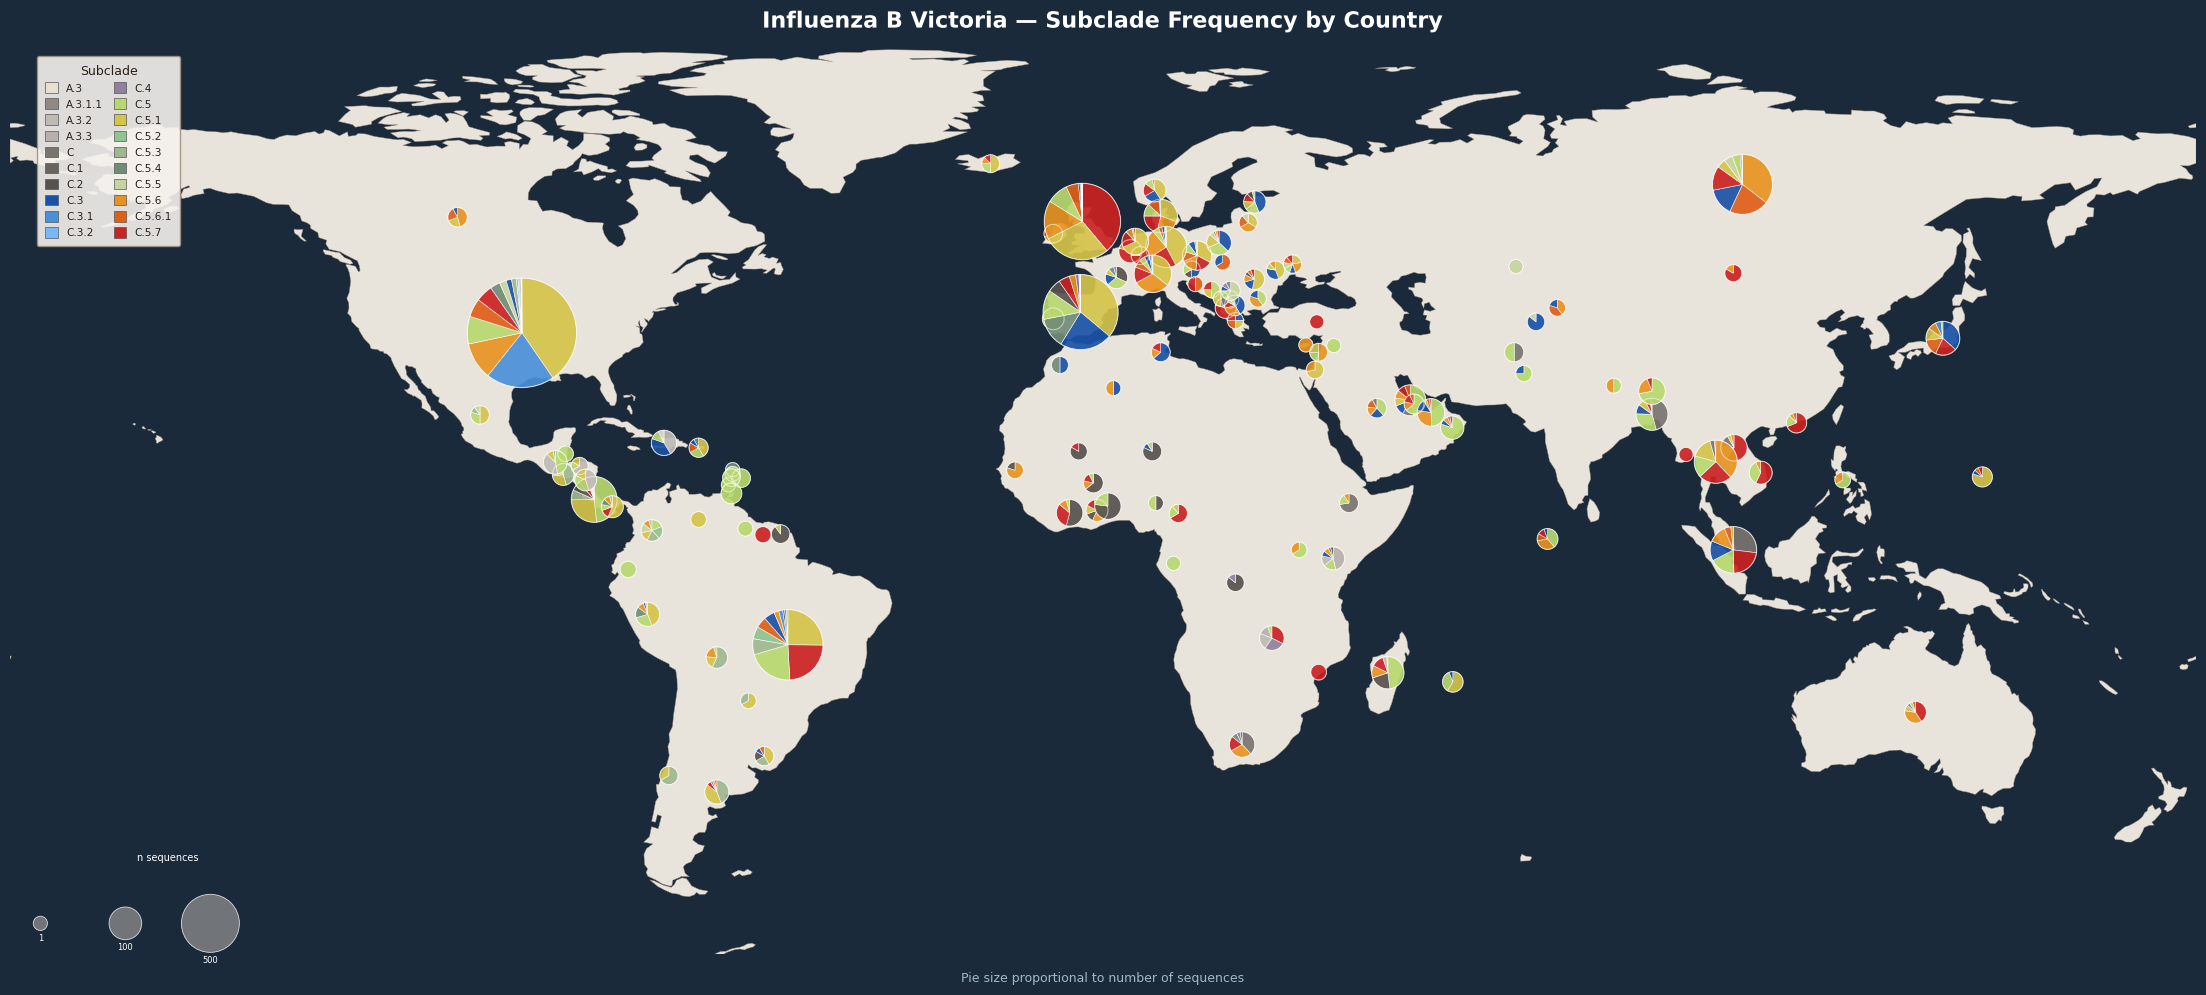

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from geodatasets import get_path
from matplotlib.patches import Wedge
from collections import defaultdict

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

# Keep only rows with both country and subclade
df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"] = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()

# ── 2. Country → (lat, lon) lookup ───────────────────────────────────────────
COUNTRY_COORDS = {
    "Afghanistan": (33.9, 67.7), "Albania": (41.2, 20.2), "Algeria": (28.0, 1.7),
    "Andorra": (42.5, 1.5), "Argentina": (-38.4, -63.6), "Australia": (-25.3, 133.8),
    "Austria": (47.5, 14.6), "Bahrain": (26.0, 50.6), "Bangladesh": (23.7, 90.4),
    "Barbados": (13.2, -59.6), "Belgium": (50.5, 4.5), "Belize": (17.2, -88.5),
    "Bhutan": (27.5, 90.4), "Bolivia": (-16.3, -63.6), "Bosnia and Herzegovina": (44.2, 17.9),
    "Brazil": (-14.2, -51.9), "Bulgaria": (42.7, 25.5), "Burkina Faso": (12.4, -1.6),
    "Cameroon": (7.4, 12.4), "Canada": (56.1, -106.3), "Chile": (-35.7, -71.5),
    "China": (35.9, 104.2), "Colombia": (4.6, -74.3), "Costa Rica": (9.7, -83.8),
    "Congo, the Democatic Republic of": (-4.0, 21.8), "Cote d'Ivoire": (7.5, -5.5),
    "Croatia": (45.1, 15.2), "Cyprus": (35.1, 33.4), "Czech Republic": (49.8, 15.5),
    "Denmark": (56.3, 9.5), "Ecuador": (-1.8, -78.2), "El Salvador": (13.8, -88.9),
    "Estonia": (58.6, 25.0), "Ethiopia": (9.1, 40.5), "France": (46.2, 2.2),
    "French Guiana": (4.0, -53.1), "Gabon": (-0.8, 11.6), "Germany": (51.2, 10.4),
    "Ghana": (7.9, -1.0), "Greece": (39.1, 21.8), "Grenada": (12.1, -61.7),
    "Guam": (13.4, 144.8), "Guatemala": (15.8, -90.2), "Guyana": (4.9, -58.9),
    "Haiti": (19.0, -72.3), "Honduras": (15.2, -86.2), "Hong Kong (SAR)": (22.3, 114.2),
    "Iceland": (64.9, -18.5), "Ireland": (53.4, -8.2), "Israel": (31.0, 34.9),
    "Italy": (41.9, 12.6), "Jamaica": (18.1, -77.3), "Japan": (36.2, 138.3),
    "Kazakhstan": (48.0, 68.0), "Kenya": (0.0, 37.9), "Korea, Republic of": (35.9, 127.8),
    "Kosovo": (42.6, 20.9), "Kyrgyzstan": (41.2, 74.8),
    "Lao, People's Democratic Republic": (18.2, 103.9), "Lebanon": (33.9, 35.5),
    "Lithuania": (55.2, 23.9), "Luxembourg": (49.8, 6.1),
    "Macedonia, the former Yogoslav Republic of": (41.6, 21.7),
    "Madagascar": (-18.8, 46.9), "Maldives": (3.2, 73.2), "Mali": (17.6, -4.0),
    "Martinique": (14.6, -61.0), "Mauritius": (-20.3, 57.6), "Mexico": (23.6, -102.6),
    "Moldova, Republic of": (47.4, 28.4), "Mongolia": (46.9, 103.8),
    "Montenegro": (42.7, 19.4), "Morocco": (31.8, -7.1), "Mozambique": (-18.7, 35.5),
    "Myanmar": (17.1, 96.0), "Nepal": (28.4, 84.1), "Netherlands": (52.1, 5.3),
    "Nicaragua": (12.9, -85.2), "Niger": (17.6, 8.1), "Nigeria": (9.1, 8.7),
    "Norway": (60.5, 8.5), "Oman": (21.5, 57.5), "Pakistan": (30.4, 69.3),
    "Panama": (8.5, -80.8), "Paraguay": (-23.4, -58.4), "Peru": (-9.2, -75.0),
    "Philippines": (12.9, 121.8), "Poland": (51.9, 19.1), "Portugal": (39.4, -8.2),
    "Puerto Rico": (18.2, -66.6), "Qatar": (25.4, 51.2), "Romania": (45.9, 24.9),
    "Russian Federation": (61.5, 105.3), "Saint Lucia": (13.9, -61.0),
    "Saint Vincent and the Grenadines": (13.3, -61.2), "Saudi Arabia": (24.7, 45.1),
    "Senegal": (14.5, -14.5), "Serbia": (44.0, 21.0), "Singapore": (1.4, 103.8),
    "Slovakia": (48.7, 19.7), "South Africa": (-30.6, 22.9), "Spain": (40.5, -3.7),
    "Suriname": (3.9, -56.0), "Switzerland": (46.8, 8.2), "Syrian Arab Republic": (35.0, 38.0),
    "Tajikistan": (38.9, 71.3), "Thailand": (15.9, 100.9), "Togo": (8.6, 0.8),
    "Trinidad and Tobago": (10.7, -61.2), "Tunisia": (33.9, 9.5), "Turkey": (38.9, 35.2),
    "Uganda": (1.4, 32.3), "Ukraine": (48.4, 31.2), "United Arab Emirates": (24.0, 54.0),
    "United Kingdom": (55.4, -3.4), "United States": (37.1, -95.7),
    "Uruguay": (-32.5, -55.8), "Venezuela": (6.4, -66.6), "Vietnam": (14.1, 108.3),
    "Zambia": (-13.1, 27.8),
    # Local institution fallback
    "JHH": (39.3, -76.6),
}

# ── 3. Subclade colour palette (matches inspiration image style) ──────────────
SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",   # deep blue
    "C.3.1":   "#4a90d9",   # mid blue
    "C.3.2":   "#7ab8f5",   # light blue
    "C.5":     "#b8d96e",   # yellow-green
    "C.5.1":   "#d4c44a",   # golden yellow
    "C.5.6":   "#e89320",   # amber
    "C.5.6.1": "#e05f18",   # burnt orange
    "C.5.7":   "#cc2222",   # red
    "A.3":     "#e8e0d0",   # light sand
    "A.1":     "#d4cfc8",   # light grey-beige
    "A.3.2":   "#c0bab4",   # medium grey
    "A.3.1":   "#a8a29c",   # grey
    "A.3.1.1": "#918a84",   # dark grey
    "C":       "#7a7470",   # charcoal grey
    "C.1":     "#6a6460",   # dark charcoal
    "C.2":     "#58524e",   # very dark
    "C.3.3":   "#b0a8e0",   # lavender
    "C.5.2":   "#90c490",   # sage green
    "C.5.4":   "#708c78",   # muted teal
    "C.5.3":   "#a0b890",   # grey-green
    "C.5.5":   "#c8d4a0",   # pale green
    "A":       "#e0dcd8",   # very light
    "A.3.3":   "#b8b0ac",   # mid grey
    "C.4":     "#9080a0",   # muted purple
}
DEFAULT_COLOR = "#aaaaaa"

# ── 4. Aggregate counts by country × subclade ─────────────────────────────────
counts = (
    df.groupby(["country", "subclade"])
    .size()
    .reset_index(name="n")
)

country_totals = counts.groupby("country")["n"].sum()

# Only keep countries we have coordinates for
valid_countries = [c for c in counts["country"].unique() if c in COUNTRY_COORDS]
counts = counts[counts["country"].isin(valid_countries)]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
world = gpd.read_file(get_path("naturalearth.land"))


fig, ax = plt.subplots(1, 1, figsize=(22, 13), facecolor="#1a2a3a")
ax.set_facecolor("#2a4a6a")

# Draw world base map
world.plot(ax=ax, color="#e8e4dc", edgecolor="#a09080", linewidth=0.3, zorder=1)

ax.set_xlim(-180, 180)
ax.set_ylim(-65, 85)
ax.axis("off")

# ── 6. Draw pie charts per country ───────────────────────────────────────────
max_n = country_totals.max()
MIN_R, MAX_R = 1.0, 9.0   # radius in degrees

for country, grp in counts.groupby("country"):
    lat, lon = COUNTRY_COORDS[country]
    total = grp["n"].sum()
    scale = np.sqrt(total / max_n)
    radius = MIN_R + (MAX_R - MIN_R) * scale

    # Build pie wedges (in data/degree space directly)
    slices = grp.sort_values("n", ascending=False)
    angles = (slices["n"] / total * 360).values
    subclades = slices["subclade"].values

    start = 90.0
    for angle, sc in zip(angles, subclades):
        color = SUBCLADE_COLORS.get(sc, DEFAULT_COLOR)
        wedge = Wedge(
            (lon, lat),
            radius,
            start - angle,
            start,
            facecolor=color,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.92,
            zorder=5,
        )
        ax.add_patch(wedge)
        start -= angle

    # White border ring
    ring = plt.Circle((lon, lat), radius, fill=False, edgecolor="white",
                      linewidth=0.8, alpha=0.5, zorder=6)
    ax.add_patch(ring)

# ── 7. Legend ─────────────────────────────────────────────────────────────────
legend_subclades = sorted(SUBCLADE_COLORS.keys())
handles = [
    mpatches.Patch(facecolor=SUBCLADE_COLORS[sc], edgecolor="#555", linewidth=0.5, label=sc)
    for sc in legend_subclades
    if sc in df["subclade"].values
]

legend = ax.legend(
    handles=handles,
    title="Subclade",
    title_fontsize=9,
    fontsize=7.5,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    framealpha=0.90,
    facecolor="#f5f2ee",
    edgecolor="#a09080",
    labelcolor="#2a2018",
    handlelength=1.2,
    handleheight=1.2,
    columnspacing=1.0,
    borderpad=0.8,
)
legend.get_title().set_color("#2a2018")

# Size reference inset (bottom-left corner of the main axes)
ref_sizes = [1, 100, 500]
ref_labels = ["1", "100", "500"]
bx = -175
by = -60
spacing = 14
ax.text(bx + spacing * 1.5, by + 10, "n sequences",
        ha="center", va="bottom", fontsize=7, color="white", zorder=10)
for i, (s, lbl) in enumerate(zip(ref_sizes, ref_labels)):
    r = MIN_R + (MAX_R - MIN_R) * np.sqrt(s / max_n)
    cx = bx + i * spacing
    cy = by
    c = plt.Circle((cx, cy), r, facecolor="#888", edgecolor="white",
                   linewidth=0.6, alpha=0.8, zorder=10)
    ax.add_patch(c)
    ax.text(cx, cy - r - 0.5, lbl, ha="center", va="top",
            fontsize=6, color="white", zorder=10)

# Title
ax.set_title(
    "Influenza B Victoria — Subclade Frequency by Country",
    fontsize=16, fontweight="bold", color="white", pad=10,
    path_effects=[pe.withStroke(linewidth=3, foreground="#1a2a3a")]
)
ax.text(0.5, -0.02, "Pie size proportional to number of sequences",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="#a0b8c8")

plt.tight_layout(pad=0.5)
out = "../figures/map_subclades_global_country.png"
plt.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out}")


# CartoPy Define function for flexible plotting 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
from geodatasets import get_path
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
from collections import defaultdict
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        GLOBAL CONFIGURATION BLOCK                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

WORLD = gpd.read_file(get_path("naturalearth.land"))

MAP_XLIM = (-180, 180)
MAP_YLIM = (-65, 85)

MAP_OCEAN_COLOR  = "#ffffff"
MAP_LAND_COLOR   = "#989E99"
MAP_BORDER_COLOR = "#a09080"
MAP_FIG_BG_COLOR = "#ffffff"
MAP_BORDER_LW    = 0.25

MAP_PROJECTION = ccrs.Robinson()
DATA_CRS = ccrs.PlateCarree()

PIE_ALPHA        = 0.70
PIE_RING_COLOR   = "none"
PIE_RING_ALPHA   = 0.7
PIE_RING_LW      = 1.2

COUNTRY_TO_REGION = {
    # North America
    "Canada": "North America", "United States": "North America", "Mexico": "North America",
    "Cuba": "North America", "Jamaica": "North America", "Haiti": "North America",
    "Puerto Rico": "North America", "Trinidad and Tobago": "North America",
    "Barbados": "North America", "Grenada": "North America",
    "Saint Lucia": "North America", "Saint Vincent and the Grenadines": "North America",
    "Guam": "North America", "Martinique": "North America", "Belize": "North America",
    "Guatemala": "North America", "Honduras": "North America", "El Salvador": "North America",
    "Nicaragua": "North America", "Costa Rica": "North America", "Panama": "North America",
    "JHH": "North America",
    # South America
    "Colombia": "South America", "Venezuela": "South America", "Brazil": "South America",
    "Peru": "South America", "Ecuador": "South America", "Bolivia": "South America",
    "Chile": "South America", "Argentina": "South America", "Uruguay": "South America",
    "Paraguay": "South America", "Guyana": "South America", "Suriname": "South America",
    "French Guiana": "South America",
    # Europe
    "United Kingdom": "Europe", "France": "Europe", "Germany": "Europe",
    "Spain": "Europe", "Italy": "Europe", "Portugal": "Europe", "Netherlands": "Europe",
    "Belgium": "Europe", "Switzerland": "Europe", "Austria": "Europe", "Norway": "Europe",
    "Denmark": "Europe", "Sweden": "Europe", "Finland": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Poland": "Europe", "Czech Republic": "Europe",
    "Slovakia": "Europe", "Romania": "Europe", "Bulgaria": "Europe", "Greece": "Europe",
    "Croatia": "Europe", "Serbia": "Europe", "Bosnia and Herzegovina": "Europe",
    "Montenegro": "Europe", "Kosovo": "Europe", "Albania": "Europe",
    "Macedonia, the former Yogoslav Republic of": "Europe",
    "Moldova, Republic of": "Europe", "Ukraine": "Europe", "Estonia": "Europe",
    "Lithuania": "Europe", "Luxembourg": "Europe", "Andorra": "Europe", "Cyprus": "Europe",
    # Africa
    "Morocco": "Africa", "Algeria": "Africa", "Tunisia": "Africa", "Nigeria": "Africa",
    "Ghana": "Africa", "Senegal": "Africa", "Mali": "Africa", "Niger": "Africa",
    "Burkina Faso": "Africa", "Cameroon": "Africa", "Gabon": "Africa",
    "Congo, the Democatic Republic of": "Africa", "Kenya": "Africa", "Uganda": "Africa",
    "Ethiopia": "Africa", "South Africa": "Africa", "Mozambique": "Africa",
    "Zambia": "Africa", "Madagascar": "Africa", "Mauritius": "Africa",
    "Togo": "Africa", "Cote d'Ivoire": "Africa", "Sudan, South": "Africa",
    # West Asia
    "Turkey": "West Asia", "Lebanon": "West Asia", "Israel": "West Asia",
    "Syrian Arab Republic": "West Asia", "Saudi Arabia": "West Asia",
    "Oman": "West Asia", "Qatar": "West Asia", "Bahrain": "West Asia",
    "United Arab Emirates": "West Asia", "Kazakhstan": "West Asia",
    "Kyrgyzstan": "West Asia", "Tajikistan": "West Asia", "Afghanistan": "West Asia",
    "Russian Federation": "West Asia",
    # South Asia
    "Pakistan": "South Asia", "Bangladesh": "South Asia", "Nepal": "South Asia",
    "Bhutan": "South Asia", "Maldives": "South Asia",
    # East Asia
    "China": "East Asia", "Hong Kong (SAR)": "East Asia", "Mongolia": "East Asia",
    "Vietnam": "East Asia", "Thailand": "East Asia", "Myanmar": "East Asia",
    "Lao, People's Democratic Republic": "East Asia", "Singapore": "East Asia",
    "Philippines": "East Asia",
    # Japan/Korea
    "Japan": "Japan/Korea", "Korea, Republic of": "Japan/Korea",
    # Oceania
    "Australia": "Oceania", "New Zealand": "Oceania", "Papua New Guinea": "Oceania",
}

REGION_COORDS = {
    "North America":  (42.0, -100.0),
    "South America":  (-15.0,  -58.0),
    "Europe":         (52.0,   15.0),
    "Africa":         (3.0,    22.0),
    "West Asia":      (35.0,   52.0),
    "South Asia":     (24.0,   78.0),
    "East Asia":      (15.0,  110.0),
    "Japan/Korea":    (37.0,  133.0),
    "Oceania":        (-27.0, 134.0),
}

SUBCLADE_COLORS = {
    "C.3":     "#1a52a8",
    "C.3.1":   "#4a90d9",
    "C.3.2":   "#7ab8f5",
    "C.5":     "#b8d96e",
    "C.5.1":   "#d4c44a",
    "C.5.6":   "#e89320",
    "C.5.6.1": "#e05f18",
    "C.5.7":   "#cc2222",
    "A.3":     "#e8e0d0",
    "A.1":     "#d4cfc8",
    "A.3.2":   "#c0bab4",
    "A.3.1":   "#a8a29c",
    "A.3.1.1": "#918a84",
    "C":       "#7a7470",
    "C.1":     "#6a6460",
    "C.2":     "#58524e",
    "C.3.3":   "#b0a8e0",
    "C.5.2":   "#90c490",
    "C.5.4":   "#708c78",
    "C.5.3":   "#a0b890",
    "C.5.5":   "#c8d4a0",
    "A":       "#e0dcd8",
    "A.3.3":   "#b8b0ac",
    "C.4":     "#9080a0",
}
DEFAULT_COLOR = "#aaaaaa"

DEFAULT_MIN_R = 5.0
DEFAULT_MAX_R = 25.0


# ══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv(
    "../source/intermediate/vic/ha/metadata_qc_location_clades_dedup_clades.tsv",
    sep="\t",
    low_memory=False,
)

df = df[df["country"].notna() & df["subclade"].notna()].copy()
df["country"]  = df["country"].str.strip()
df["subclade"] = df["subclade"].str.strip()
df["date"]     = pd.to_datetime(df["date"], errors="coerce")
df["custom_region"] = df["country"].map(COUNTRY_TO_REGION)
df = df[df["custom_region"].notna() & df["date"].notna()]

print(f"Loaded {len(df):,} sequences across {df['custom_region'].nunique()} regions")
print(df["custom_region"].value_counts().to_string())


# ══════════════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def _deg_to_map_units(lon, lat, deg, projection):
    """Convert a radius in degrees to approximate map units."""
    from cartopy.crs import PlateCarree
    x1, y1 = projection.transform_point(lon, lat, PlateCarree())
    x2, y2 = projection.transform_point(lon + deg, lat, PlateCarree())
    return abs(x2 - x1)


def _generate_grey_palette(subclades, start_grey=0.35, end_grey=0.75):
    """Generate a dict of grey colors for a list of subclades."""
    n = len(subclades)
    if n == 1:
        greys = [start_grey]
    else:
        greys = np.linspace(start_grey, end_grey, n)
    return {sc: f"#{int(g*255):02x}{int(g*255):02x}{int(g*255):02x}" 
            for sc, g in zip(subclades, greys)}


def _compute_radius_deg(n, max_n, min_r, max_r, size_scale):
    """
    Compute pie radius in degrees - SINGLE SOURCE OF TRUTH.
    Uses sqrt scaling so area is proportional to count.
    """
    size_ratio = np.sqrt(n / max_n)
    radius_deg = (min_r + (max_r - min_r) * size_ratio) * size_scale
    return radius_deg


def _add_size_legend(
    ax,
    ref_sizes,
    max_n,
    min_r,
    max_r,
    size_scale,
    projection,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    title="n sequences",
    fontsize=7,
    title_fontsize=8,
    bubble_color="#888888",
    bubble_alpha=0.7,
    horizontal=True,
    spacing=1.0,
    label_gap=0,
    bubble_overlap=0.5,
):
    """
    Add a size legend using the EXACT same scaling as the map pies.
    
    Parameters
    ----------
    ax : matplotlib axes
        The axes to add the legend to.
    ref_sizes : list
        List of reference sizes (e.g., [50, 500, 1000]).
    max_n : int
        Maximum n value from the data (for scaling).
    min_r, max_r : float
        Min/max radius in degrees (same as map pies).
    size_scale : float
        Multiplier for sizes (same as map pies).
    projection : cartopy CRS
        Map projection for coordinate conversion.
    loc : str
        Location string (e.g., "lower right").
    bbox_to_anchor : tuple
        Fine-tune position (x, y) in axes coordinates.
    title : str
        Title for the size legend.
    fontsize : int
        Font size for labels.
    title_fontsize : int
        Font size for title.
    bubble_color : str
        Fill color for reference bubbles.
    bubble_alpha : float
        Transparency of reference bubbles.
    horizontal : bool
        If True, arrange bubbles horizontally.
    spacing : float
        Base spacing multiplier.
    label_gap : float
        Vertical gap between bubble and label. 0 = touching, negative = closer.
    bubble_overlap : float
        Controls horizontal overlap. 0 = no overlap, higher = more overlap.
    
    Returns
    -------
    AnchoredOffsetbox
        The size legend object.
    """
    ref_lon, ref_lat = 0, 0
    
    # Calculate radii using same function as pies
    radii_map_units = []
    for s in ref_sizes:
        r_deg = _compute_radius_deg(s, max_n, min_r, max_r, size_scale)
        r_map = _deg_to_map_units(ref_lon, ref_lat, r_deg, projection)
        radii_map_units.append(r_map)
    
    # Get axes size to scale markers
    fig = ax.figure
    bbox = ax.get_position()
    ax_width_inches = fig.get_figwidth() * bbox.width
    
    x0, x1 = ax.get_xlim()
    map_width_units = x1 - x0
    
    units_per_inch = map_width_units / ax_width_inches
    points_per_unit = 72 / units_per_inch
    
    # Convert radii to points
    marker_sizes_pts = [r * points_per_unit for r in radii_map_units]
    
    bubble_label_pairs = []
    max_marker = max(marker_sizes_pts)
    
    for s, msize in zip(ref_sizes, marker_sizes_pts):
        # Drawing area sized for this circle
        da_height = msize * 2.2
        da_width = msize * 2.2
        
        da = DrawingArea(da_width, da_height, 0, 0)
        
        circle = plt.Circle(
            (da_width / 2, da_height / 2),
            msize,
            facecolor=bubble_color,
            edgecolor="black",
            linewidth=0.6,
            alpha=bubble_alpha,
        )
        da.add_artist(circle)
        
        label = TextArea(
            f"{s:,}",
            textprops=dict(fontsize=fontsize, color="black", ha="center"),
        )
        
        # label_gap controls vertical spacing
        pair = VPacker(children=[da, label], align="center", pad=0, sep=label_gap)
        bubble_label_pairs.append(pair)
    
    title_text = TextArea(
        title,
        textprops=dict(fontsize=title_fontsize, color="black", fontweight="bold"),
    )
    
    if horizontal:
        # Calculate overlap-based separation
        base_sep = spacing * 10
        overlap_adjustment = bubble_overlap * max_marker * 1.5
        final_sep = max(base_sep - overlap_adjustment, -max_marker)
        
        bubbles_box = HPacker(
            children=bubble_label_pairs,
            align="bottom",
            pad=0,
            sep=final_sep,
        )
    else:
        base_sep = spacing * 8
        overlap_adjustment = bubble_overlap * max_marker
        final_sep = max(base_sep - overlap_adjustment, -max_marker * 0.5)
        
        bubbles_box = VPacker(
            children=bubble_label_pairs,
            align="center",
            pad=0,
            sep=final_sep,
        )
    
    full_legend = VPacker(
        children=[title_text, bubbles_box],
        align="center",
        pad=0,
        sep=6,
    )
    
    anchored_box = AnchoredOffsetbox(
        loc=loc,
        child=full_legend,
        pad=0.1,
        frameon=False,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    
    ax.add_artist(anchored_box)
    return anchored_box


def save_legend_separately(
    colors,
    subclades,
    save_path,
    title="Subclade",
    ncol=1,
    figsize=(3, 6),
    dpi=300,
):
    """Save subclade color legend as a separate file."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    
    handles = [
        mpatches.Patch(
            facecolor=colors.get(sc, DEFAULT_COLOR),
            edgecolor="#555", linewidth=0.5, label=sc,
        )
        for sc in sorted(subclades)
    ]
    
    legend = ax.legend(
        handles=handles,
        title=title, title_fontsize=11,
        fontsize=9,
        loc="center",
        ncol=ncol,
        framealpha=0.95, facecolor="#f5f2ee",
        edgecolor="#a09080", labelcolor="#2a2018",
        handlelength=1.5, handleheight=1.3,
        columnspacing=1.0, borderpad=1.0,
        labelspacing=0.8,
    )
    legend.get_title().set_color("#2a2018")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Subclade legend saved → {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN PLOTTING FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def plot_subclade_map(
    df,
    title           = "Influenza B Victoria — Subclade Frequency by Region",
    date_start      = None,
    date_end        = None,
    color_dict      = None,
    projection      = MAP_PROJECTION,
    figsize         = (18, 10),
    min_r           = DEFAULT_MIN_R,
    max_r           = DEFAULT_MAX_R,
    size_scale      = 1.0,
    # ── Pie aesthetics ──
    pie_alpha       = PIE_ALPHA,
    pie_edge_color  = "none",
    pie_edge_lw     = 0,
    pie_ring        = True,
    # ── n= labels on pies ──
    show_n_label    = True,
    n_label_min_r   = 0.0,
    # ── Subclade legend ──
    show_subclade_legend = True,
    subclade_legend_loc  = "lower right",
    subclade_legend_anchor = (0.99, 0.12),
    subclade_legend_ncol = 1,
    subclade_legend_save_path = None,
    # ── Size legend ──
    show_size_legend = True,
    size_legend_values = None,
    size_legend_loc = "lower right",
    size_legend_anchor = (0.68, 0.05),
    size_legend_title = "n sequences",
    size_legend_horizontal = True,
    size_legend_spacing = 1.0,
    size_legend_label_gap = 0,
    size_legend_bubble_overlap = 0.5,
    # ── Output ──
    save_path       = None,
    dpi             = 180,
):
    """
    Plot subclade frequency map with pie charts per global region.
    
    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe with columns: country, subclade, date, custom_region.
    title : str
        Figure title.
    date_start : str or None
        ISO date "YYYY-MM-DD". Rows before this are excluded.
    date_end : str or None
        ISO date "YYYY-MM-DD". Rows after this are excluded.
    color_dict : dict or None
        Subclade → hex color overrides.
    projection : cartopy CRS
        Map projection.
    figsize : tuple
        Figure (width, height) in inches.
    min_r : float
        Minimum pie radius in degrees.
    max_r : float
        Maximum pie radius in degrees.
    size_scale : float
        Multiplier applied to all pie radii.
    pie_alpha : float
        Transparency of pie charts.
    pie_edge_color : str
        Edge color for pie slices. Use "none" for no edges.
    pie_edge_lw : float
        Edge linewidth for pie slices. Use 0 for no edges.
    pie_ring : bool
        If True, draw outer ring around pies.
    show_n_label : bool
        If True, show "n=X,XXX" beneath each pie.
    n_label_min_r : float
        Only show n label if pie radius >= this threshold.
    show_subclade_legend : bool
        If True, display the subclade color legend.
    subclade_legend_loc : str
        Location for subclade legend.
    subclade_legend_anchor : tuple
        Fine-tune position (x, y) in axes coordinates.
    subclade_legend_ncol : int
        Number of columns in subclade legend.
    subclade_legend_save_path : str or None
        If provided, save subclade legend as a separate file.
    show_size_legend : bool
        If True, display the size reference legend.
    size_legend_values : list or None
        Reference sizes to show. Auto-generated if None.
    size_legend_loc : str
        Location for size legend.
    size_legend_anchor : tuple
        Fine-tune position (x, y) in axes coordinates.
    size_legend_title : str
        Title for size legend.
    size_legend_horizontal : bool
        If True, arrange size bubbles horizontally.
    size_legend_spacing : float
        Base spacing multiplier for size legend.
    size_legend_label_gap : float
        Vertical gap between bubble and label. Negative = closer.
    size_legend_bubble_overlap : float
        Horizontal overlap amount. Higher = more overlap.
    save_path : str or None
        File path to save figure.
    dpi : int
        Resolution for saved figure.

    Returns
    -------
    fig, ax
    """

    # ── Filter by date ────────────────────────────────────────────────────────
    fdf = df.copy()
    if date_start:
        fdf = fdf[fdf["date"] >= date_start]
    if date_end:
        fdf = fdf[fdf["date"] <= date_end]

    if fdf.empty:
        print("⚠️  No data in the specified date range.")
        return None, None

    # ── Build color scheme ────────────────────────────────────────────────────
    all_subclades = sorted(fdf["subclade"].unique())
    colors = _generate_grey_palette(all_subclades, start_grey=0.35, end_grey=0.75)
    
    if SUBCLADE_COLORS:
        colors.update(SUBCLADE_COLORS)
    if color_dict:
        colors.update(color_dict)

    # ── Aggregate counts ──────────────────────────────────────────────────────
    counts = (
        fdf.groupby(["custom_region", "subclade"])
        .size()
        .reset_index(name="n")
    )
    region_totals = counts.groupby("custom_region")["n"].sum()
    
    max_n = region_totals.max()
    min_n = region_totals.min()
    
    print(f"Region counts: min={min_n:,}, max={max_n:,}")

    # ── Save subclade legend separately if requested ──────────────────────────
    if subclade_legend_save_path:
        save_legend_separately(
            colors=colors,
            subclades=all_subclades,
            save_path=subclade_legend_save_path,
            dpi=dpi,
        )

    # ── Figure & Cartopy axes ─────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor=MAP_FIG_BG_COLOR)
    ax  = fig.add_subplot(1, 1, 1, projection=projection)
    ax.set_global()
    ax.set_facecolor(MAP_OCEAN_COLOR)

    ax.add_feature(cfeature.LAND,      facecolor=MAP_LAND_COLOR,   zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor=MAP_OCEAN_COLOR,  zorder=0)
    ax.add_feature(cfeature.COASTLINE, edgecolor=MAP_BORDER_COLOR,
                   linewidth=MAP_BORDER_LW + 0.1, zorder=2)
    ax.add_feature(cfeature.BORDERS,   edgecolor=MAP_BORDER_COLOR,
                   linewidth=MAP_BORDER_LW, zorder=2)

    gl = ax.gridlines(
        crs=DATA_CRS,
        draw_labels=False,
        linewidth=0.5,
        color='#c0c0c0',
        alpha=0.6,
        linestyle='--',
        zorder=3
    )
    gl.xlocator = plt.matplotlib.ticker.MultipleLocator(30)
    gl.ylocator = plt.matplotlib.ticker.MultipleLocator(30)

    # ── Draw pies ─────────────────────────────────────────────────────────────
    for region, grp in counts.groupby("custom_region"):
        lat, lon  = REGION_COORDS[region]
        total     = region_totals[region]

        # Use single source of truth for radius calculation
        radius_deg = _compute_radius_deg(total, max_n, min_r, max_r, size_scale)
        radius     = _deg_to_map_units(lon, lat, radius_deg, projection)

        cx, cy = projection.transform_point(lon, lat, DATA_CRS)

        slices    = grp.sort_values("n", ascending=False)
        angles    = (slices["n"] / total * 360).values
        subclades = slices["subclade"].values

        start = 90.0
        for angle, sc in zip(angles, subclades):
            wedge = Wedge(
                (cx, cy), radius,
                start - angle, start,
                facecolor=colors.get(sc, DEFAULT_COLOR),
                edgecolor=pie_edge_color,
                linewidth=pie_edge_lw,
                alpha=pie_alpha,
                transform=ax.transData,
                zorder=5,
            )
            ax.add_patch(wedge)
            start -= angle

        # Outer ring
        if pie_ring:
            ring = plt.Circle(
                (cx, cy), radius,
                fill=False, edgecolor=PIE_RING_COLOR,
                linewidth=PIE_RING_LW, alpha=PIE_RING_ALPHA,
                transform=ax.transData, zorder=6,
            )
            ax.add_patch(ring)

        # n labels
        if show_n_label and radius_deg >= n_label_min_r:
            lx, ly = projection.transform_point(lon, lat - radius_deg - 1.2, DATA_CRS)
            ax.text(
                lx, ly,
                f"n={total:,}",
                ha="center", va="top",
                fontsize=6.5, color="black", fontweight="bold",
                transform=ax.transData, zorder=7,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            )

    # ── Subclade Legend ───────────────────────────────────────────────────────
    if show_subclade_legend:
        present = sorted(fdf["subclade"].unique())
        handles = [
            mpatches.Patch(
                facecolor=colors.get(sc, DEFAULT_COLOR),
                edgecolor="#555", linewidth=0.5, label=sc,
            )
            for sc in present
        ]
        legend = ax.legend(
            handles=handles,
            title="Subclade", title_fontsize=9,
            fontsize=8,
            loc=subclade_legend_loc,
            bbox_to_anchor=subclade_legend_anchor,
            ncol=subclade_legend_ncol,
            framealpha=0.90, facecolor="#f5f2ee",
            edgecolor="#a09080", labelcolor="#2a2018",
            handlelength=1.2, handleheight=1.1,
            columnspacing=0.9, borderpad=0.8,
            labelspacing=0.6,
        )
        legend.get_title().set_color("#2a2018")

    # ── Size Legend ───────────────────────────────────────────────────────────
    if show_size_legend:
        # Auto-generate sensible reference values if not provided
        if size_legend_values is None:
            candidates = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
            candidates = [c for c in candidates if c <= max_n]
            
            if len(candidates) >= 3:
                size_legend_values = [
                    candidates[0],
                    candidates[len(candidates)//2],
                    candidates[-1]
                ]
            else:
                size_legend_values = [int(min_n), int(max_n)]
        
        _add_size_legend(
            ax,
            ref_sizes=size_legend_values,
            max_n=max_n,
            min_r=min_r,
            max_r=max_r,
            size_scale=size_scale,
            projection=projection,
            loc=size_legend_loc,
            bbox_to_anchor=size_legend_anchor,
            title=size_legend_title,
            horizontal=size_legend_horizontal,
            spacing=size_legend_spacing,
            label_gap=size_legend_label_gap,
            bubble_overlap=size_legend_bubble_overlap,
        )

    # ── Title ─────────────────────────────────────────────────────────────────
    ax.set_title(
        title,
        fontsize=14, fontweight="bold", color="black", pad=8,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

    # ── Subtitle ──────────────────────────────────────────────────────────────
    subtitle_parts = []
    if date_start or date_end:
        s = date_start or "start"
        e = date_end   or "present"
        subtitle_parts.append(f"{s}  →  {e}")
    subtitle_parts.append(f"n = {len(fdf):,} sequences")
    subtitle = "   ·   ".join(subtitle_parts)

    fig.text(
        0.5, 0.01, subtitle,
        ha="center", va="bottom",
        fontsize=9, color="#333333",
    )

    fig.patch.set_facecolor(MAP_FIG_BG_COLOR)
    plt.tight_layout(pad=0.2)
    plt.subplots_adjust(bottom=0.06, top=0.94)

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")

    return fig, ax

Loaded 8,836 sequences across 9 regions
custom_region
Europe           2989
North America    2754
South America     963
West Asia         784
East Asia         612
Africa            432
South Asia        168
Japan/Korea       112
Oceania            22


# plot

Region counts: min=4, max=906
Subclade legend saved → ../figures/map_NH2023-24_subclade-legend.png
Saved → ../figures/map_NH2023-24.png


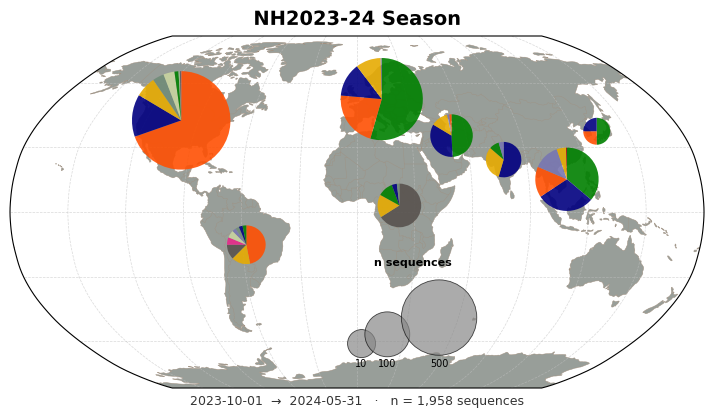

Region counts: min=5, max=1,192
Subclade legend saved → ../figures/map_NH2024-25_subclade-legend.png
Saved → ../figures/map_NH2024-25.png


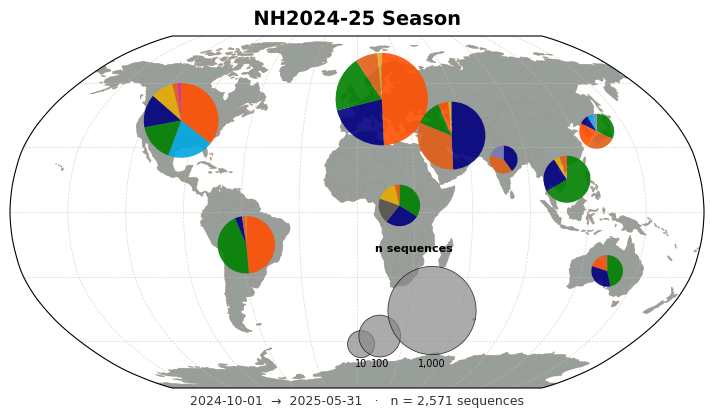

Region counts: min=1, max=528
Subclade legend saved → ../figures/map_NH2025-26_subclade-legend.png
Saved → ../figures/map_NH2025-26.png


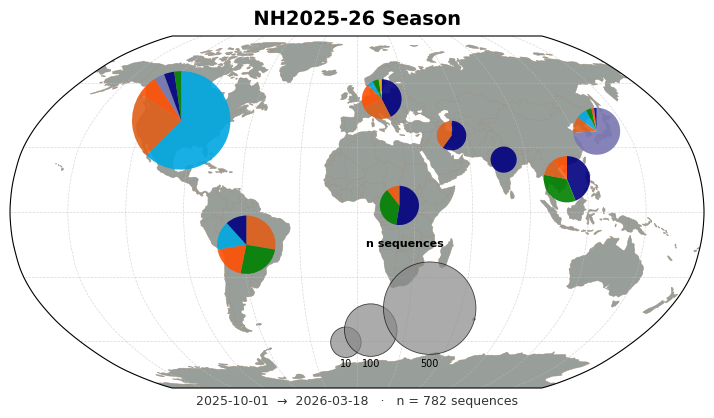

Region counts: min=22, max=2,989
Subclade legend saved → ../figures/map_2020-26.png_subclade-legend.png
Saved → ../figures/map_2020-26.png


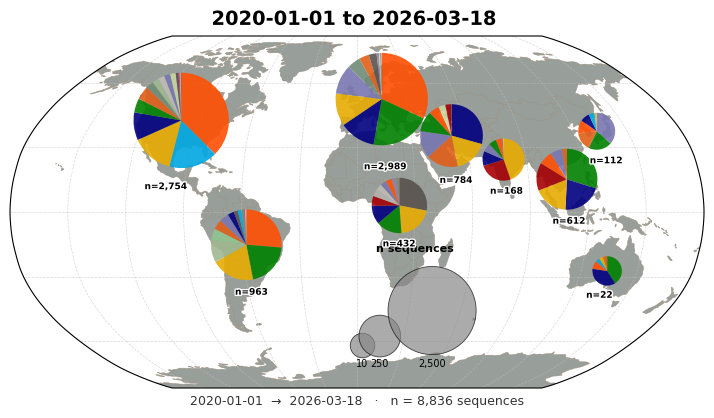

In [129]:
highlight_colors = {
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C": "#A50104" # vaccine
        }

# Plot by season - 2023-2025 
# --- 2023-2024 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "NH2023-24 Season",
    date_start   = "2023-10-01",
    date_end     = "2024-05-31",
    color_dict   = highlight_colors,
    show_n_label=False,
    pie_alpha=0.9,
    size_scale=2, 
    figsize      = (8, 4),
    min_r        = 3.0,
    max_r        = 14.0,
    save_path    = "../figures/map_NH2023-24.png",
    show_subclade_legend=False,
    show_size_legend=True,
    subclade_legend_save_path="../figures/map_NH2023-24_subclade-legend.png"
)
plt.show()

# --- 2024-2025 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "NH2024-25 Season",
    date_start   = "2024-10-01",
    date_end     = "2025-05-31",
    color_dict   = highlight_colors,
    show_n_label=False,
    pie_alpha=0.9,
    size_scale=2, 
    figsize      = (8, 4),
    min_r        = 3.0,
    max_r        = 14.0,
    save_path    = "../figures/map_NH2024-25.png",
    show_subclade_legend=False,
    show_size_legend=True,
    subclade_legend_save_path="../figures/map_NH2024-25_subclade-legend.png"
)
plt.show()

# --- 2025-2026 Season ---
fig, ax = plot_subclade_map(
    df,
    title        = "NH2025-26 Season",
    date_start   = "2025-10-01",
    date_end     = "2026-03-18",
    color_dict   = highlight_colors,
    show_n_label=False,
    pie_alpha=0.9,
    size_scale=2, 
    figsize      = (8, 4),
    min_r        = 3.0,
    max_r        = 14.0,
    save_path    = "../figures/map_NH2025-26.png",
    show_subclade_legend=False,
    show_size_legend=True,
    subclade_legend_save_path="../figures/map_NH2025-26_subclade-legend.png"
)
plt.show()


# wide net
fig, ax = plot_subclade_map(
    df,
    title        = "2020-01-01 to 2026-03-18 ",
    date_start   = "2020-01-01",
    date_end     = "2026-03-18",
    color_dict   = highlight_colors,
    show_n_label=True,
    pie_alpha=0.9,
    size_scale=2, 
    figsize      = (8, 4),
    min_r        = 3.0,
    max_r        = 14.0,
    save_path    = "../figures/map_2020-26.png",
    show_subclade_legend=False,
    show_size_legend=True,
    subclade_legend_save_path="../figures/map_2020-26.png_subclade-legend.png"
)

plt.show()

# Figure: Function for faceting maps 

Sharing the same bubble legend size



In [132]:
def plot_subclade_map_facet(
    df,
    periods,
    color_dict      = None,
    projection      = MAP_PROJECTION,
    figsize         = (16, 12),
    nrows           = 2,
    ncols           = 2,
    min_r           = DEFAULT_MIN_R,
    max_r           = DEFAULT_MAX_R,
    size_scale      = 1.0,
    # ── Pie aesthetics ──
    pie_alpha       = PIE_ALPHA,
    pie_edge_color  = "none",
    pie_edge_lw     = 0,
    pie_ring        = True,
    # ── n= labels on pies ──
    show_n_label    = False,
    n_label_min_r   = 0.0,
    # ── Size legend (shared) ──
    show_size_legend = True,
    size_legend_values = None,
    size_legend_position = "bottom",  # "bottom", "right", or None for per-panel
    size_legend_title = "n sequences",
    size_legend_label_gap = -2,
    size_legend_bubble_overlap = 0.6,
    # ── Subclade legend (shared) ──
    show_subclade_legend = True,
    subclade_legend_position = "right",  # "right", "bottom", or None
    subclade_legend_ncol = 1,
    subclade_legend_x = 0.88,      # NEW: x position for subclade legend
    subclade_legend_y_center = 0.5, # NEW: y center for subclade legend
    size_legend_x = 0.88,          # NEW: x position for size legend  
    size_legend_y = 0.15,          # NEW: y position for size legend
    # ── Spacing ──
    wspace          = 0.05,
    hspace          = 0.12,
    # ── Output ──
    save_path       = None,
    dpi             = 180,
):
    """
    Create a faceted panel of subclade maps with consistent scaling across all panels.
    
    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe with columns: country, subclade, date, custom_region.
    periods : list of dict
        Each dict defines a panel with keys:
        - 'title': str, panel title
        - 'date_start': str or None, ISO date "YYYY-MM-DD"
        - 'date_end': str or None, ISO date "YYYY-MM-DD"
        Example:
        [
            {'title': 'NH2023-24', 'date_start': '2023-10-01', 'date_end': '2024-05-31'},
            {'title': 'NH2024-25', 'date_start': '2024-10-01', 'date_end': '2025-05-31'},
        ]
    color_dict : dict or None
        Subclade → hex color overrides.
    projection : cartopy CRS
        Map projection.
    figsize : tuple
        Figure (width, height) in inches.
    nrows, ncols : int
        Grid layout for panels.
    min_r, max_r : float
        Min/max pie radius in degrees.
    size_scale : float
        Multiplier applied to all pie radii.
    pie_alpha : float
        Transparency of pie charts.
    pie_edge_color : str
        Edge color for pie slices.
    pie_edge_lw : float
        Edge linewidth for pie slices.
    pie_ring : bool
        If True, draw outer ring around pies.
    show_n_label : bool
        If True, show "n=X,XXX" beneath each pie.
    n_label_min_r : float
        Only show n label if pie radius >= this threshold.
    show_size_legend : bool
        If True, display a shared size legend.
    size_legend_values : list or None
        Reference sizes to show. Auto-generated if None.
    size_legend_position : str
        Where to place shared size legend: "bottom", "right", or None for per-panel.
    size_legend_title : str
        Title for size legend.
    size_legend_label_gap : float
        Vertical gap between bubble and label.
    size_legend_bubble_overlap : float
        Horizontal overlap amount.
    show_subclade_legend : bool
        If True, display a shared subclade legend.
    subclade_legend_position : str
        Where to place shared subclade legend: "right", "bottom".
    subclade_legend_ncol : int
        Number of columns in subclade legend.
    wspace, hspace : float
        Spacing between panels.
    save_path : str or None
        File path to save figure.
    dpi : int
        Resolution for saved figure.
    
    Returns
    -------
    fig, axes : matplotlib figure and array of axes
    """
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 1: Calculate GLOBAL max_n across all periods for consistent scaling
    # ══════════════════════════════════════════════════════════════════════════
    
    global_max_n = 0
    all_subclades = set()
    period_data = []
    
    for period in periods:
        fdf = df.copy()
        if period.get('date_start'):
            fdf = fdf[fdf["date"] >= period['date_start']]
        if period.get('date_end'):
            fdf = fdf[fdf["date"] <= period['date_end']]
        
        if not fdf.empty:
            counts = (
                fdf.groupby(["custom_region", "subclade"])
                .size()
                .reset_index(name="n")
            )
            region_totals = counts.groupby("custom_region")["n"].sum()
            period_max = region_totals.max()
            global_max_n = max(global_max_n, period_max)
            all_subclades.update(fdf["subclade"].unique())
        
        period_data.append({
            'fdf': fdf,
            'title': period.get('title', ''),
            'date_start': period.get('date_start'),
            'date_end': period.get('date_end'),
        })
    
    print(f"Global max_n across all periods: {global_max_n:,}")
    print(f"Total unique subclades: {len(all_subclades)}")
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 2: Build unified color scheme
    # ══════════════════════════════════════════════════════════════════════════
    
    all_subclades = sorted(all_subclades)
    colors = _generate_grey_palette(all_subclades, start_grey=0.35, end_grey=0.75)
    
    if SUBCLADE_COLORS:
        colors.update(SUBCLADE_COLORS)
    if color_dict:
        colors.update(color_dict)
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 3: Create figure with space for shared legends
    # ══════════════════════════════════════════════════════════════════════════
    
    # Adjust figure layout based on legend positions
    if subclade_legend_position == "right" or size_legend_position == "right":
        fig = plt.figure(figsize=(figsize[0] + 2, figsize[1]), facecolor=MAP_FIG_BG_COLOR)
        # Leave space on right for legend
        if subclade_legend_position == "right":
            right_margin = 0.85
        else:
            right_margin = 0.92
    else:
        fig = plt.figure(figsize=figsize, facecolor=MAP_FIG_BG_COLOR)
        right_margin = 0.98
    
    if size_legend_position == "bottom":
        bottom_margin = 0.10
    else:
        bottom_margin = 0.05
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 4: Create subplot grid
    # ══════════════════════════════════════════════════════════════════════════
    
    axes = []
    for i, pdata in enumerate(period_data):
        ax = fig.add_subplot(
            nrows, ncols, i + 1,
            projection=projection
        )
        axes.append(ax)
        
        fdf = pdata['fdf']
        
        if fdf.empty:
            ax.set_title(pdata['title'], fontsize=11, fontweight="bold", pad=5)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", 
                    transform=ax.transAxes, fontsize=12, color="gray")
            continue
        
        # Setup map
        ax.set_global()
        ax.set_facecolor(MAP_OCEAN_COLOR)
        ax.add_feature(cfeature.LAND, facecolor=MAP_LAND_COLOR, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor=MAP_OCEAN_COLOR, zorder=0)
        ax.add_feature(cfeature.COASTLINE, edgecolor=MAP_BORDER_COLOR,
                       linewidth=MAP_BORDER_LW + 0.1, zorder=2)
        ax.add_feature(cfeature.BORDERS, edgecolor=MAP_BORDER_COLOR,
                       linewidth=MAP_BORDER_LW, zorder=2)
        
        # Gridlines
        gl = ax.gridlines(
            crs=DATA_CRS,
            draw_labels=False,
            linewidth=0.4,
            color='#c0c0c0',
            alpha=0.5,
            linestyle='--',
            zorder=3
        )
        gl.xlocator = plt.matplotlib.ticker.MultipleLocator(30)
        gl.ylocator = plt.matplotlib.ticker.MultipleLocator(30)
        
        # Aggregate counts
        counts = (
            fdf.groupby(["custom_region", "subclade"])
            .size()
            .reset_index(name="n")
        )
        region_totals = counts.groupby("custom_region")["n"].sum()
        
        # ── Draw pies using GLOBAL max_n ──
        for region, grp in counts.groupby("custom_region"):
            lat, lon = REGION_COORDS[region]
            total = region_totals[region]
            
            # Use GLOBAL max_n for consistent scaling
            radius_deg = _compute_radius_deg(total, global_max_n, min_r, max_r, size_scale)
            radius = _deg_to_map_units(lon, lat, radius_deg, projection)
            
            cx, cy = projection.transform_point(lon, lat, DATA_CRS)
            
            slices = grp.sort_values("n", ascending=False)
            angles = (slices["n"] / total * 360).values
            subclades_list = slices["subclade"].values
            
            start = 90.0
            for angle, sc in zip(angles, subclades_list):
                wedge = Wedge(
                    (cx, cy), radius,
                    start - angle, start,
                    facecolor=colors.get(sc, DEFAULT_COLOR),
                    edgecolor=pie_edge_color,
                    linewidth=pie_edge_lw,
                    alpha=pie_alpha,
                    transform=ax.transData,
                    zorder=5,
                )
                ax.add_patch(wedge)
                start -= angle
            
            # Outer ring
            if pie_ring:
                ring = plt.Circle(
                    (cx, cy), radius,
                    fill=False, edgecolor=PIE_RING_COLOR,
                    linewidth=PIE_RING_LW, alpha=PIE_RING_ALPHA,
                    transform=ax.transData, zorder=6,
                )
                ax.add_patch(ring)
            
            # n labels
            if show_n_label and radius_deg >= n_label_min_r:
                lx, ly = projection.transform_point(lon, lat - radius_deg - 1.2, DATA_CRS)
                ax.text(
                    lx, ly,
                    f"n={total:,}",
                    ha="center", va="top",
                    fontsize=5.5, color="black", fontweight="bold",
                    transform=ax.transData, zorder=7,
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="white")],
                )
        
        # Panel title
        ax.set_title(
            pdata['title'],
            fontsize=11, fontweight="bold", color="black", pad=5,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
        )
        
        # Panel subtitle (date range & count)
        subtitle_parts = []
        if pdata['date_start'] or pdata['date_end']:
            s = pdata['date_start'] or "start"
            e = pdata['date_end'] or "present"
            subtitle_parts.append(f"{s} → {e}")
        subtitle_parts.append(f"n = {len(fdf):,}")
        subtitle = "  ·  ".join(subtitle_parts)
        
        ax.text(
            0.5, -0.02, subtitle,
            ha="center", va="top",
            fontsize=7, color="#444444",
            transform=ax.transAxes,
        )
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 5: Add shared legends - UPDATED POSITIONING
    # ══════════════════════════════════════════════════════════════════════════
    
    # ── Shared subclade legend ──
    if show_subclade_legend and subclade_legend_position == "right":
        handles = [
            mpatches.Patch(
                facecolor=colors.get(sc, DEFAULT_COLOR),
                edgecolor="#555", linewidth=0.5, label=sc,
            )
            for sc in all_subclades
        ]
        
        # Position legend closer to plots and vertically centered
        legend_height = min(0.6, len(all_subclades) * 0.04)
        legend_y_start = subclade_legend_y_center - legend_height / 2
        
        legend_ax = fig.add_axes([
            subclade_legend_x,           # x position (closer = smaller value)
            legend_y_start,              # y start
            0.10,                         # width
            legend_height                 # height
        ])
        legend_ax.axis('off')
        
        legend = legend_ax.legend(
            handles=handles,
            title="Subclade", title_fontsize=10,
            fontsize=9,
            loc="center",
            ncol=subclade_legend_ncol,
            framealpha=0.95, facecolor="#f5f2ee",
            edgecolor="#a09080", labelcolor="#2a2018",
            handlelength=1.2, handleheight=1.0,
            columnspacing=0.8, borderpad=0.6,
            labelspacing=0.4,
        )
        legend.get_title().set_color("#2a2018")
    
    # ── Shared size legend ──
    if show_size_legend and size_legend_position == "right":
        _add_size_legend_figure(
            fig,
            ref_sizes=size_legend_values,
            max_n=global_max_n,
            min_r=min_r,
            max_r=max_r,
            size_scale=size_scale,
            projection=projection,
            position=(size_legend_x, size_legend_y),
            title=size_legend_title,
            horizontal=False,
            label_gap=size_legend_label_gap,
            bubble_overlap=size_legend_bubble_overlap,
        )
    
    # ══════════════════════════════════════════════════════════════════════════
    # STEP 6: Adjust layout and save
    # ══════════════════════════════════════════════════════════════════════════
    
    plt.subplots_adjust(
        left=0.02,
        right=right_margin,
        bottom=bottom_margin,
        top=0.95,
        wspace=wspace,
        hspace=hspace,
    )
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")
    
    return fig, axes


def _add_size_legend_figure(
    fig,
    ref_sizes,
    max_n,
    min_r,
    max_r,
    size_scale,
    projection,
    position=(0.5, 0.02),
    title="n sequences",
    fontsize=8,
    title_fontsize=9,
    bubble_color="#888888",
    bubble_alpha=0.7,
    horizontal=True,
    label_gap=0,
    bubble_overlap=0.5,
):
    """
    Add a size legend to the figure (not axes) for shared legend across panels.
    
    This creates a small axes just for the legend.
    """
    
    # Create a small axes for the legend
    if horizontal:
        legend_ax = fig.add_axes([position[0] - 0.15, position[1], 0.3, 0.08])
    else:
        legend_ax = fig.add_axes([position[0], position[1], 0.08, 0.25])
    
    legend_ax.axis('off')
    
    # Calculate relative marker sizes
    # We'll use a simple scaling for the legend display
    marker_sizes = []
    for s in ref_sizes:
        r_deg = _compute_radius_deg(s, max_n, min_r, max_r, size_scale)
        marker_sizes.append(r_deg)

    # Normalize relative to max
    max_marker = max(marker_sizes)
    marker_sizes = [m / max_marker * 25 for m in marker_sizes]
    
    bubble_label_pairs = []
    for s, msize in zip(ref_sizes, marker_sizes):
        da_size = max_marker * 2.5
        da = DrawingArea(da_size, da_size, 0, 0)
        
        circle = plt.Circle(
            (da_size / 2, da_size / 2),
            msize,
            facecolor=bubble_color,
            edgecolor="none",
            linewidth=0.6,
            alpha=bubble_alpha,
        )
        da.add_artist(circle)
        
        label = TextArea(
            f"{s:,}",
            textprops=dict(fontsize=fontsize, color="black", ha="center"),
        )
        
        pair = VPacker(children=[da, label], align="center", pad=0, sep=label_gap)
        bubble_label_pairs.append(pair)
    
    title_text = TextArea(
        title,
        textprops=dict(fontsize=title_fontsize, color="black", fontweight="bold"),
    )
    
    if horizontal:
        base_sep = 10
        overlap_adjustment = bubble_overlap * max_marker * 1.5
        final_sep = max(base_sep - overlap_adjustment, -max_marker)
        
        bubbles_box = HPacker(
            children=bubble_label_pairs,
            align="bottom",
            pad=0,
            sep=final_sep,
        )
    else:
        base_sep = 8
        overlap_adjustment = bubble_overlap * max_marker
        final_sep = max(base_sep - overlap_adjustment, -max_marker * 0.5)
        
        bubbles_box = VPacker(
            children=bubble_label_pairs,
            align="center",
            pad=0,
            sep=final_sep,
        )
    
    full_legend = VPacker(
        children=[title_text, bubbles_box],
        align="center",
        pad=0,
        sep=6,
    )
    
    anchored_box = AnchoredOffsetbox(
        loc="center",
        child=full_legend,
        pad=0.1,
        frameon=False,
        bbox_to_anchor=(0.5, 0.5),
        bbox_transform=legend_ax.transAxes,
        borderpad=0,
    )
    
    legend_ax.add_artist(anchored_box)
    return anchored_box

Global max_n across all periods: 1,192
Total unique subclades: 9
Saved → ../figures/map_facet_2panel.png


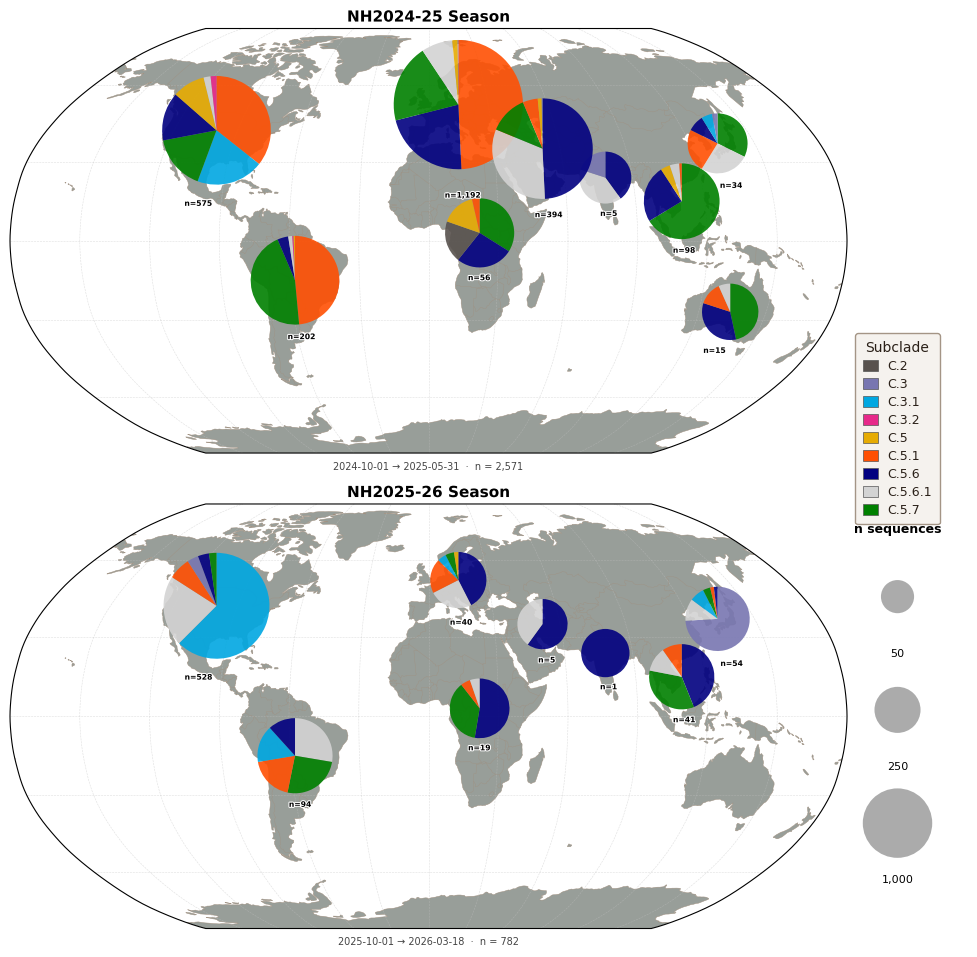

In [134]:
highlight_colors = {
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.6.1": "lightgrey",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C": "#A50104" # vaccine
        }

# Create faceted plot with adjusted positioning
fig, axes = plot_subclade_map_facet(
    df,
    periods         = periods,
    color_dict      = highlight_colors,
    figsize         = (12, 10),
    nrows           = 2,
    ncols           = 1,
    # LARGER BUBBLES
    min_r           = 4.0,
    max_r           = 13.0,
    size_scale      = 2.5,
    pie_alpha       = 0.90,
    pie_edge_color  = "none",
    pie_ring        = True,
    show_n_label    = True,
    # Size legend - positioned closer
    show_size_legend = True,
    size_legend_values = [50, 250, 1000],
    size_legend_position = "right",
    size_legend_x   = 0.73,           # Closer to plot (default was 0.88)
    size_legend_y   = 0.15,           # Vertical position
    size_legend_label_gap = -1,
    size_legend_bubble_overlap = 0.3,
    # Subclade legend - positioned closer and centered
    show_subclade_legend = True,
    subclade_legend_position = "right",
    subclade_legend_ncol = 1,
    subclade_legend_x = 0.72,         # Closer to plot
    subclade_legend_y_center = 0.55,  # Vertically centered
    # Spacing
    wspace          = 0.1,
    hspace          = 0.12,
    # Output
    save_path       = "../figures/map_facet_2panel.png",
    dpi             = 300,
)
plt.show()

In [ ]:
Diagnostics Scripts

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  DIAGNOSTIC SCRIPT - DATA FILTERING ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def diagnose_data_filtering(df, verbose=True):
    """
    Analyze how many rows are being filtered at each step of the pipeline.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe loaded from TSV
    verbose : bool
        Print detailed breakdown by country/region
    
    Returns
    -------
    dict with filtering statistics
    """
    
    print("=" * 80)
    print("DATA FILTERING DIAGNOSTIC REPORT")
    print("=" * 80)
    
    stats = {}
    
    # ── Step 0: Original data ─────────────────────────────────────────────────
    total_original = len(df)
    stats['original'] = total_original
    print(f"\n📊 STEP 0: Original data")
    print(f"   Total rows: {total_original:,}")
    
    # ── Step 1: Missing country ───────────────────────────────────────────────
    missing_country = df["country"].isna().sum()
    has_country = df["country"].notna()
    stats['missing_country'] = missing_country
    stats['has_country'] = has_country.sum()
    
    print(f"\n📊 STEP 1: Filter by country presence")
    print(f"   ✓ Has country: {has_country.sum():,}")
    print(f"   ✗ Missing country: {missing_country:,} ({missing_country/total_original*100:.2f}%)")
    
    # ── Step 2: Missing subclade ──────────────────────────────────────────────
    df_temp = df[has_country].copy()
    missing_subclade = df_temp["subclade"].isna().sum()
    has_subclade = df_temp["subclade"].notna()
    stats['missing_subclade'] = missing_subclade
    stats['has_both_country_subclade'] = has_subclade.sum()
    
    print(f"\n📊 STEP 2: Filter by subclade presence (among rows with country)")
    print(f"   ✓ Has subclade: {has_subclade.sum():,}")
    print(f"   ✗ Missing subclade: {missing_subclade:,} ({missing_subclade/len(df_temp)*100:.2f}%)")
    
    # ── Step 3: Custom region mapping ─────────────────────────────────────────
    df_temp = df_temp[has_subclade].copy()
    df_temp["country"] = df_temp["country"].str.strip()
    df_temp["custom_region"] = df_temp["country"].map(COUNTRY_TO_REGION)
    
    missing_region = df_temp["custom_region"].isna().sum()
    has_region = df_temp["custom_region"].notna()
    stats['missing_region_mapping'] = missing_region
    stats['has_region'] = has_region.sum()
    
    print(f"\n📊 STEP 3: Map country → custom region")
    print(f"   ✓ Mapped to region: {has_region.sum():,}")
    print(f"   ✗ No region mapping: {missing_region:,} ({missing_region/len(df_temp)*100:.2f}%)")
    
    if missing_region > 0 and verbose:
        unmapped_countries = df_temp[df_temp["custom_region"].isna()]["country"].value_counts()
        print(f"\n   ⚠️  Countries without region mapping:")
        for country, count in unmapped_countries.head(20).items():
            print(f"      • {country}: {count:,} sequences")
        if len(unmapped_countries) > 20:
            print(f"      ... and {len(unmapped_countries) - 20} more countries")
    
    # ── Step 4: Missing date ──────────────────────────────────────────────────
    df_temp = df_temp[has_region].copy()
    df_temp["date"] = pd.to_datetime(df_temp["date"], errors="coerce")
    missing_date = df_temp["date"].isna().sum()
    has_date = df_temp["date"].notna()
    stats['missing_date'] = missing_date
    stats['final_kept'] = has_date.sum()
    
    print(f"\n📊 STEP 4: Filter by date validity")
    print(f"   ✓ Valid date: {has_date.sum():,}")
    print(f"   ✗ Missing/invalid date: {missing_date:,} ({missing_date/len(df_temp)*100:.2f}%)")
    
    # ── Final summary ─────────────────────────────────────────────────────────
    final_df = df_temp[has_date].copy()
    total_dropped = total_original - len(final_df)
    
    print(f"\n" + "=" * 80)
    print(f"SUMMARY")
    print(f"=" * 80)
    print(f"Started with:        {total_original:,} sequences")
    print(f"Final dataset:       {len(final_df):,} sequences")
    print(f"Total dropped:       {total_dropped:,} sequences ({total_dropped/total_original*100:.2f}%)")
    print(f"\nRetention rate:      {len(final_df)/total_original*100:.2f}%")
    
    # ── Breakdown by filter reason ────────────────────────────────────────────
    print(f"\n📉 SEQUENCES DROPPED BY REASON:")
    print(f"   Missing country:           {missing_country:,}")
    print(f"   Missing subclade:          {missing_subclade:,}")
    print(f"   Country not in region map: {missing_region:,}")
    print(f"   Missing/invalid date:      {missing_date:,}")
    
    # ── Regional distribution ─────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"FINAL DATA DISTRIBUTION BY REGION")
    print(f"=" * 80)
    region_counts = final_df["custom_region"].value_counts()
    for region, count in region_counts.items():
        pct = count / len(final_df) * 100
        print(f"   {region:20s}: {count:6,} ({pct:5.2f}%)")
    
    # ── Countries in final dataset ────────────────────────────────────────────
    if verbose:
        print(f"\n" + "=" * 80)
        print(f"TOP 30 COUNTRIES IN FINAL DATASET")
        print(f"=" * 80)
        country_counts = final_df["country"].value_counts().head(30)
        for country, count in country_counts.items():
            region = COUNTRY_TO_REGION.get(country, "Unknown")
            pct = count / len(final_df) * 100
            print(f"   {country:35s} ({region:15s}): {count:6,} ({pct:5.2f}%)")
    
    # ── Date range ────────────────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"DATE RANGE")
    print(f"=" * 80)
    print(f"   Earliest: {final_df['date'].min().strftime('%Y-%m-%d')}")
    print(f"   Latest:   {final_df['date'].max().strftime('%Y-%m-%d')}")
    print(f"   Span:     {(final_df['date'].max() - final_df['date'].min()).days} days")
    
    # ── Subclade distribution ─────────────────────────────────────────────────
    print(f"\n" + "=" * 80)
    print(f"SUBCLADE DISTRIBUTION")
    print(f"=" * 80)
    subclade_counts = final_df["subclade"].value_counts()
    for sc, count in subclade_counts.items():
        pct = count / len(final_df) * 100
        print(f"   {sc:15s}: {count:6,} ({pct:5.2f}%)")
    
    print(f"\n" + "=" * 80)
    
    return stats, final_df

# ══════════════════════════════════════════════════════════════════════════════
#  CHECK FOR UNMAPPED COUNTRIES - DETAILED VERSION
# ══════════════════════════════════════════════════════════════════════════════

def find_unmapped_countries(df):
    """
    Find all countries that have data but aren't in COUNTRY_TO_REGION mapping.
    
    Returns a DataFrame with unmapped countries and their sequence counts.
    """
    
    print("=" * 80)
    print("UNMAPPED COUNTRIES ANALYSIS")
    print("=" * 80)
    
    # Get countries with valid data
    valid_df = df[df["country"].notna() & df["subclade"].notna()].copy()
    valid_df["country"] = valid_df["country"].str.strip()
    
    # Check which are unmapped
    valid_df["has_mapping"] = valid_df["country"].map(COUNTRY_TO_REGION).notna()
    
    unmapped = valid_df[~valid_df["has_mapping"]].copy()
    
    if len(unmapped) == 0:
        print("\n✓ All countries with data are mapped to regions!")
        return pd.DataFrame()
    
    # Count by country
    unmapped_summary = (
        unmapped.groupby("country")
        .agg({
            "subclade": "count",
            "date": lambda x: f"{x.min().strftime('%Y-%m-%d')} to {x.max().strftime('%Y-%m-%d')}"
        })
        .rename(columns={"subclade": "n_sequences", "date": "date_range"})
        .sort_values("n_sequences", ascending=False)
    )
    
    print(f"\n⚠️  Found {len(unmapped_summary)} unmapped countries with {len(unmapped):,} sequences\n")
    print(unmapped_summary.to_string())
    
    # Generate code to add to COUNTRY_TO_REGION
    print(f"\n" + "=" * 80)
    print("SUGGESTED ADDITIONS TO COUNTRY_TO_REGION:")
    print("=" * 80)
    print("\n# Add these lines to your COUNTRY_TO_REGION dictionary:\n")
    
    for country in unmapped_summary.index:
        # Try to suggest a region (you'll need to manually verify)
        print(f'    "{country}": "REGION_NAME",  # TODO: assign correct region')
    
    return unmapped_summary


# ══════════════════════════════════════════════════════════════════════════════
#  COMPARE BEFORE/AFTER FILTERING
# ══════════════════════════════════════════════════════════════════════════════

def compare_filtering_by_region(df):
    """
    Show how many sequences each region loses due to missing dates or other filters.
    """
    
    print("=" * 80)
    print("REGIONAL FILTERING IMPACT")
    print("=" * 80)
    
    # Apply country/subclade filters
    step1 = df[df["country"].notna() & df["subclade"].notna()].copy()
    step1["country"] = step1["country"].str.strip()
    step1["custom_region"] = step1["country"].map(COUNTRY_TO_REGION)
    
    # Before date filter
    before = step1[step1["custom_region"].notna()].copy()
    before_counts = before["custom_region"].value_counts()
    
    # After date filter
    before["date"] = pd.to_datetime(before["date"], errors="coerce")
    after = before[before["date"].notna()].copy()
    after_counts = after["custom_region"].value_counts()
    
    # Compare
    print(f"\n{'Region':<20s} {'Before Date Filter':>18s} {'After Date Filter':>18s} {'Lost':>10s} {'% Lost':>8s}")
    print("-" * 80)
    
    all_regions = sorted(set(before_counts.index) | set(after_counts.index))
    
    for region in all_regions:
        before_n = before_counts.get(region, 0)
        after_n = after_counts.get(region, 0)
        lost = before_n - after_n
        pct_lost = (lost / before_n * 100) if before_n > 0 else 0
        
        print(f"{region:<20s} {before_n:>18,} {after_n:>18,} {lost:>10,} {pct_lost:>7.2f}%")
    
    total_before = before_counts.sum()
    total_after = after_counts.sum()
    total_lost = total_before - total_after
    
    print("-" * 80)
    print(f"{'TOTAL':<20s} {total_before:>18,} {total_after:>18,} {total_lost:>10,} {total_lost/total_before*100:>7.2f}%")
    print()


# ══════════════════════════════════════════════════════════════════════════════
#  RUN ALL DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════

# Run full diagnostic
stats, final_df = diagnose_data_filtering(df, verbose=True)

print("\n\n")

# Find unmapped countries
unmapped = find_unmapped_countries(df)

print("\n\n")

# Regional filtering impact
compare_filtering_by_region(df)

# Save unmapped countries to file for reference
if len(unmapped) > 0:
    unmapped.to_csv("unmapped_countries.csv")
    print(f"\n💾 Saved unmapped countries to: unmapped_countries.csv")

DATA FILTERING DIAGNOSTIC REPORT

📊 STEP 0: Original data
   Total rows: 8,840

📊 STEP 1: Filter by country presence
   ✓ Has country: 8,840
   ✗ Missing country: 0 (0.00%)

📊 STEP 2: Filter by subclade presence (among rows with country)
   ✓ Has subclade: 8,840
   ✗ Missing subclade: 0 (0.00%)


NameError: name 'COUNTRY_TO_REGION' is not defined

# Frequencies

Eventually refactor and combined with the (06_frequencies)[notebooks/06_frequencies.qmd] notebook


# Function number 1 with data points 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy.ndimage import gaussian_filter1d
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

GREY_CMAP = plt.cm.get_cmap("Greys")

DEFAULT_HIGHLIGHT_COLORS = {}

# Dot aesthetics
DOT_SIZE       = 18
DOT_ALPHA      = 0.55
DOT_ZORDER     = 4

# Line aesthetics
LINE_LW_GREY   = 1.0
LINE_LW_COLOR  = 2.2
LINE_ALPHA     = 0.90
LINE_ZORDER    = 5

# Smoothing
SMOOTH_SIGMA   = 3.0

# Figure aesthetics — NOW ALL WHITE
FIG_BG_COLOR   = "#ffffff"
AXES_BG_COLOR  = "#ffffff"  # Changed from "#f9f9f9"
SHOW_GRID      = False      # New: toggle grid on/off

# ══════════════════════════════════════════════════════════════════════════════
#  TEXT SIZE CONFIGURATION — SEPARATE X AND Y AXIS SIZES
# ══════════════════════════════════════════════════════════════════════════════

TITLE_FONTSIZE       = 16
SUBTITLE_FONTSIZE    = 9
LEGEND_FONTSIZE      = 9

# Y-axis text sizes
Y_AXIS_LABEL_FONTSIZE = 14
Y_TICK_LABEL_FONTSIZE = 12

# X-axis text sizes
X_AXIS_LABEL_FONTSIZE = 14
X_TICK_LABEL_FONTSIZE = 12

# X-axis rotation
X_LABEL_ROTATION     = 45
X_LABEL_HA           = "right"


# ══════════════════════════════════════════════════════════════════════════════
#  HELPER — build a dynamic grey palette for N subclades
# ══════════════════════════════════════════════════════════════════════════════

def _build_grey_palette(subclades):
    """
    Return a dict {subclade: grey_hex} with evenly spaced greys for each
    subclade, ordered alphabetically. Avoids pure white and pure black.
    """
    n = len(subclades)
    palette = {}
    for i, sc in enumerate(sorted(subclades)):
        intensity = 0.25 + 0.50 * (i / max(n - 1, 1))
        r, g, b, _ = GREY_CMAP(intensity)
        palette[sc] = "#{:02x}{:02x}{:02x}".format(
            int(r * 255), int(g * 255), int(b * 255)
        )
    return palette


# ══════════════════════════════════════════════════════════════════════════════
#  CORE FUNCTION — single region frequency plot
# ══════════════════════════════════════════════════════════════════════════════

def plot_subclade_frequency(
    df,
    region,
    title                = None,
    date_start           = None,
    date_end             = None,
    color_dict           = None,
    figsize              = (12, 5),
    smooth_sigma         = SMOOTH_SIGMA,
    dot_size             = DOT_SIZE,
    dot_alpha            = DOT_ALPHA,
    min_month_n          = 5,
    show_legend          = True,
    legend_ncol          = 4,
    save_path            = None,
    dpi                  = 180,
    # New: separate axis text size parameters
    x_tick_fontsize      = X_TICK_LABEL_FONTSIZE,
    y_tick_fontsize      = Y_TICK_LABEL_FONTSIZE,
    x_label_fontsize     = X_AXIS_LABEL_FONTSIZE,
    y_label_fontsize     = Y_AXIS_LABEL_FONTSIZE,
    title_fontsize       = TITLE_FONTSIZE,
    # New: background/grid control
    show_grid            = SHOW_GRID,
    bg_color             = AXES_BG_COLOR,
):
    """
    Plot subclade frequency over time for a single region.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe with columns: custom_region, subclade, date.
    region : str
        Region name matching values in df["custom_region"].
    title : str or None
        Axes title. Defaults to the region name.
    date_start : str or None
        ISO date "YYYY-MM-DD" to filter data from.
    date_end : str or None
        ISO date "YYYY-MM-DD" to filter data until.
    color_dict : dict or None
        {subclade: colour} overrides for highlighting.
    figsize : tuple
        Figure (width, height) in inches.
    smooth_sigma : float
        Gaussian smoothing sigma. Higher = smoother. 0 = no smoothing.
    dot_size : float
        Scatter point size.
    dot_alpha : float
        Dot transparency (0–1).
    min_month_n : int
        Minimum sequences per month to include.
    show_legend : bool
        Show subclade legend below the plot.
    legend_ncol : int
        Number of columns in the legend.
    save_path : str or None
        File path to save the figure.
    dpi : int
        Resolution for saved figure.
    x_tick_fontsize : float
        Font size for x-axis tick labels.
    y_tick_fontsize : float
        Font size for y-axis tick labels.
    x_label_fontsize : float
        Font size for x-axis label.
    y_label_fontsize : float
        Font size for y-axis label.
    title_fontsize : float
        Font size for plot title.
    show_grid : bool
        Whether to show grid lines.
    bg_color : str
        Background color for the plot area.

    Returns
    -------
    fig, ax
    """

    colors = dict(DEFAULT_HIGHLIGHT_COLORS)
    if color_dict:
        colors.update(color_dict)

    # ── Filter ────────────────────────────────────────────────────────────────
    fdf = df[df["custom_region"] == region].copy()
    if date_start:
        fdf = fdf[fdf["date"] >= date_start]
    if date_end:
        fdf = fdf[fdf["date"] <= date_end]

    if fdf.empty:
        print(f"⚠️  No data for region '{region}' in the specified date range.")
        return None, None

    # ── Monthly aggregation ───────────────────────────────────────────────────
    fdf["month"] = fdf["date"].dt.to_period("M")

    month_totals = fdf.groupby("month").size().rename("total")

    sc_month = (
        fdf.groupby(["month", "subclade"])
        .size()
        .reset_index(name="count")
        .merge(month_totals, on="month")
    )
    sc_month["freq"] = sc_month["count"] / sc_month["total"]

    sc_month = sc_month[sc_month["total"] >= min_month_n]

    if sc_month.empty:
        print(f"⚠️  Not enough data for region '{region}' (min_month_n={min_month_n}).")
        return None, None

    sc_month["month_dt"] = sc_month["month"].dt.to_timestamp()

    all_subclades = sorted(sc_month["subclade"].unique())
    grey_palette  = _build_grey_palette(all_subclades)

    highlighted   = [sc for sc in all_subclades if sc in colors]
    background    = [sc for sc in all_subclades if sc not in colors]
    draw_order    = background + highlighted

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor=FIG_BG_COLOR)
    ax.set_facecolor(bg_color)

    # Grid — only if requested
    if show_grid:
        ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
    else:
        ax.grid(False)
    
    ax.set_axisbelow(True)

    # Spines — clean look
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["bottom", "left"]:
        ax.spines[spine].set_edgecolor("#333333")
        ax.spines[spine].set_linewidth(0.8)

    all_months = sorted(sc_month["month_dt"].unique())

    for sc in draw_order:
        is_highlighted = sc in colors
        color  = colors[sc] if is_highlighted else grey_palette[sc]
        lw     = LINE_LW_COLOR if is_highlighted else LINE_LW_GREY
        zorder_dot  = DOT_ZORDER + (10 if is_highlighted else 0)
        zorder_line = LINE_ZORDER + (10 if is_highlighted else 0)
        alpha_dot   = dot_alpha if not is_highlighted else min(dot_alpha + 0.2, 1.0)

        sc_data = sc_month[sc_month["subclade"] == sc].sort_values("month_dt")

        if sc_data.empty:
            continue

        # ── Dots ──────────────────────────────────────────────────────────────
        ax.scatter(
            sc_data["month_dt"], sc_data["freq"],
            s=dot_size, color=color, alpha=alpha_dot,
            zorder=zorder_dot, linewidths=0,
        )

        # ── Smoothed trendline ────────────────────────────────────────────────
        sc_indexed = (
            sc_data.set_index("month_dt")["freq"]
            .reindex(all_months, fill_value=0)
        )

        if smooth_sigma > 0 and len(sc_indexed) >= 3:
            smoothed = gaussian_filter1d(sc_indexed.values.astype(float), sigma=smooth_sigma)
            smoothed = np.clip(smoothed, 0, 1)
        else:
            smoothed = sc_indexed.values

        ax.plot(
            sc_indexed.index, smoothed,
            color=color, linewidth=lw, alpha=LINE_ALPHA,
            zorder=zorder_line, solid_capstyle="round",
        )

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlim(
        pd.Timestamp(all_months[0])  - pd.DateOffset(weeks=2),
        pd.Timestamp(all_months[-1]) + pd.DateOffset(weeks=2),
    )
    
    # Y-axis label with separate size
    ax.set_ylabel("Frequency", fontsize=y_label_fontsize)
    ax.set_xlabel("")  # No x-axis label by default
    
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))

    # X-axis ticks
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_minor_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    
    # Separate tick label sizes for x and y
    ax.tick_params(axis="x", which="major", labelsize=x_tick_fontsize, length=4)
    ax.tick_params(axis="x", which="minor", length=2)
    ax.tick_params(axis="y", which="major", labelsize=y_tick_fontsize, length=4)
    ax.tick_params(axis="y", which="minor", length=2)
    
    # Rotate x-axis labels
    plt.setp(ax.xaxis.get_majorticklabels(), 
             rotation=X_LABEL_ROTATION, 
             ha=X_LABEL_HA,
             rotation_mode="anchor")

    # Title
    ax.set_title(
        title if title else region,
        fontsize=title_fontsize, fontweight="bold", pad=10, color="#222222",
    )

    # Subtitle
    total_seqs = len(fdf)
    date_info  = f"{fdf['date'].min().strftime('%b %Y')} – {fdf['date'].max().strftime('%b %Y')}"
    ax.text(
        0.99, 0.98,
        f"n = {total_seqs:,}  ·  {date_info}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=SUBTITLE_FONTSIZE, color="#888888",
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    if show_legend:
        handles = []
        for sc in draw_order:
            color = colors[sc] if sc in colors else grey_palette[sc]
            lw    = LINE_LW_COLOR if sc in colors else LINE_LW_GREY
            h = plt.Line2D(
                [0], [0], color=color, linewidth=lw + 0.5,
                marker="o", markersize=5, markerfacecolor=color,
                markeredgewidth=0, label=sc,
            )
            handles.append(h)

        ax.legend(
            handles=handles,
            ncol=legend_ncol,
            fontsize=LEGEND_FONTSIZE,
            loc="upper left",
            bbox_to_anchor=(0, -0.22),
            frameon=False,
            handlelength=1.8,
            handletextpad=0.5,
            columnspacing=1.0,
        )
        fig.subplots_adjust(bottom=0.28)

    plt.tight_layout(rect=[0, 0.05 if show_legend else 0.0, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")

    return fig, ax


# ══════════════════════════════════════════════════════════════════════════════
#  CONVENIENCE — plot all regions at once
# ══════════════════════════════════════════════════════════════════════════════

def plot_all_regions(
    df,
    color_dict           = None,
    date_start           = None,
    date_end             = None,
    figsize              = (12, 5),
    smooth_sigma         = SMOOTH_SIGMA,
    min_month_n          = 5,
    save_dir             = None,
    dpi                  = 180,
    filename_prefix      = "subclade_freq",
    # Pass through text size options
    x_tick_fontsize      = X_TICK_LABEL_FONTSIZE,
    y_tick_fontsize      = Y_TICK_LABEL_FONTSIZE,
    x_label_fontsize     = X_AXIS_LABEL_FONTSIZE,
    y_label_fontsize     = Y_AXIS_LABEL_FONTSIZE,
    title_fontsize       = TITLE_FONTSIZE,
    show_grid            = SHOW_GRID,
    bg_color             = AXES_BG_COLOR,
):
    """
    Call plot_subclade_frequency() for every region present in the data.
    """
    regions = sorted(df["custom_region"].dropna().unique())
    results = {}

    for region in regions:
        save_path = None
        if save_dir:
            safe_name = region.replace("/", "_").replace(" ", "_")
            save_path = f"{save_dir}/{filename_prefix}_{safe_name}.png"

        fig, ax = plot_subclade_frequency(
            df,
            region           = region,
            date_start       = date_start,
            date_end         = date_end,
            color_dict       = color_dict,
            figsize          = figsize,
            smooth_sigma     = smooth_sigma,
            min_month_n      = min_month_n,
            save_path        = save_path,
            dpi              = dpi,
            x_tick_fontsize  = x_tick_fontsize,
            y_tick_fontsize  = y_tick_fontsize,
            x_label_fontsize = x_label_fontsize,
            y_label_fontsize = y_label_fontsize,
            title_fontsize   = title_fontsize,
            show_grid        = show_grid,
            bg_color         = bg_color,
        )
        results[region] = (fig, ax)
        plt.show()

    return results

# Function #2 Without datapoints and normalized x axis

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy.ndimage import gaussian_filter1d
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.grid'] = False


def plot_subclade_frequency(
    df,
    region,
    title=None,
    color_dict=None,
    figsize=(12, 5),
    smooth_sigma=SMOOTH_SIGMA,
    min_month_n=5,
    show_legend=True,
    legend_ncol=4,
    save_path=None,
    dpi=180,
    x_tick_fontsize=X_TICK_LABEL_FONTSIZE,
    y_tick_fontsize=Y_TICK_LABEL_FONTSIZE,
    x_label_fontsize=X_AXIS_LABEL_FONTSIZE,
    y_label_fontsize=Y_AXIS_LABEL_FONTSIZE,
    title_fontsize=TITLE_FONTSIZE,
    show_grid=SHOW_GRID,
    bg_color=AXES_BG_COLOR,
    date_start=None,
    date_end=None,
    global_start=None,   
    global_end=None,
    show_points=False,
):
    colors = dict(DEFAULT_HIGHLIGHT_COLORS)
    if color_dict:
        colors.update(color_dict)

    # ==== Filter ====
    fdf = df[df["custom_region"] == region].copy()
    if date_start:
        fdf = fdf[fdf["date"] >= date_start]
    if date_end:
        fdf = fdf[fdf["date"] <= date_end]

    # ==== Monthly aggregation ====
    if not fdf.empty:
        fdf["month"] = fdf["date"].dt.to_period("M")
        month_totals = fdf.groupby("month").size().rename("total")
        sc_month = (
            fdf.groupby(["month", "subclade"])
                .size()
                .reset_index(name="count")
                .merge(month_totals, on="month")
        )
        sc_month["freq"] = sc_month["count"] / sc_month["total"]
        sc_month = sc_month[sc_month["total"] >= min_month_n]
        sc_month["month_dt"] = sc_month["month"].dt.to_timestamp()
    else:
        sc_month = pd.DataFrame([])

    # ==== Global axis enforcement ====
    x_start = pd.to_datetime(global_start) if global_start else (
        sc_month["month_dt"].min() if not sc_month.empty else None)
    x_end = pd.to_datetime(global_end) if global_end else (
        sc_month["month_dt"].max() if not sc_month.empty else None)
    if x_start is None or x_end is None:
        print(f"⚠️ No data for region '{region}'")
        return None, None
    all_months = pd.date_range(x_start, x_end, freq='MS')

    fig, ax = plt.subplots(figsize=figsize, facecolor=FIG_BG_COLOR)
    ax.set_facecolor(bg_color)
    if show_grid:
        ax.yaxis.grid(False, color=GRID_COLOR, linewidth=0.8, alpha=GRID_ALPHA, zorder=0)
        ax.xaxis.grid(False, color=GRID_COLOR, linewidth=0.8, alpha=GRID_ALPHA, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["bottom", "left"]:
        ax.spines[spine].set_edgecolor("#aaaaaa")
        ax.spines[spine].set_linewidth(1.0)

    # ==== No Data: grey background everywhere ====
    if sc_month.empty or sc_month["month_dt"].min() is None or sc_month["month_dt"].max() is None:
        ax.axvspan(x_start, x_end, color='#eeeeee80', zorder=1)
        ax.text(
            0.5, 0.08, 'no data available', transform=ax.transAxes, ha='center', va='bottom',
            fontsize=10, color='#cccccc', alpha=0.9
        )
        # Title and subtitle still drawn:
        ax.text(
            0.02, 0.97, title if title else region,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=title_fontsize, fontweight="bold", color="#222222",
            path_effects=[pe.withStroke(linewidth=2, foreground='white', alpha=0.15)],
        )
        ax.text(
            0.98, 0.97, "n = 0  ·  --",         
            transform=ax.transAxes, ha="right", va="top",
            fontsize=SUBTITLE_FONTSIZE, color="#888888",
            path_effects=[pe.withStroke(linewidth=1, foreground='white', alpha=0.25)],
        )
        _format_freq_axes(ax, all_months, x_tick_fontsize, y_tick_fontsize, y_label_fontsize)
        if save_path:
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
        return fig, ax

    # ==== Shade out areas with no data for region ====
    region_min = sc_month["month_dt"].min()
    region_max = sc_month["month_dt"].max()
    if region_min > x_start:
        ax.axvspan(x_start, region_min, color='#eeeeee80', zorder=1)
        ax.text(
            0.01, 0.08, 'no data available', transform=ax.transAxes, ha='left', va='bottom',
            fontsize=10, color='#cccccc', alpha=0.8, rotation = 90
        )
    if region_max < x_end:
        ax.axvspan(region_max, x_end, color='#eeeeee80', zorder=1)
        ax.text(
            0.99, 0.08, 'no data available', transform=ax.transAxes, ha='right', va='bottom', 
            fontsize=10, color='#cccccc', alpha=0.8, rotation = 90
        )

    # ==== Plot Lines, Points ====
    all_subclades = sorted(sc_month["subclade"].unique())
    grey_palette = _build_grey_palette(all_subclades)
    highlighted = [sc for sc in all_subclades if sc in colors]
    background = [sc for sc in all_subclades if sc not in colors]
    draw_order = background + highlighted

    smoothed_data = {}
    for sc in draw_order:
        sc_data = sc_month[sc_month["subclade"] == sc].sort_values("month_dt")
        if sc_data.empty:
            smoothed_data[sc] = pd.Series(0, index=all_months)
        else:
            sc_indexed = (
                sc_data.set_index("month_dt")["freq"]
                    .reindex(all_months, fill_value=0)
            )
            smoothed = gaussian_filter1d(
                sc_indexed.values.astype(float), sigma=smooth_sigma
            ) if smooth_sigma > 0 and len(sc_indexed) >= 3 else sc_indexed.values
            smoothed = np.clip(smoothed, 0, 1)
            smoothed_data[sc] = pd.Series(smoothed, index=all_months)

        # Draw line
        color = colors[sc] if sc in colors else grey_palette[sc]
        lw = LINE_LW_COLOR if sc in colors else LINE_LW_GREY
        zorder = LINE_ZORDER + (10 if sc in colors else 0)
        ax.plot(
            all_months, smoothed_data[sc].values,
            color=color, linewidth=lw, alpha=LINE_ALPHA, zorder=zorder,
        )
        # Draw points
        if show_points and not sc_data.empty:
            ax.scatter(
                sc_data["month_dt"], sc_data["freq"],
                color=color, s=26, alpha=0.99,
                edgecolor='white', linewidth=0.7, zorder=zorder + 1
            )

    # ==== Axes formatting ====
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlim(x_start - pd.DateOffset(weeks=2), x_end + pd.DateOffset(weeks=2))
    _format_freq_axes(ax, all_months, x_tick_fontsize, y_tick_fontsize, y_label_fontsize)

    # ==== Title & Top-right subtitle ====
    total_seqs = len(fdf)
    if not fdf.empty:
        date_info = f"{fdf['date'].min().strftime('%b %Y')} – {fdf['date'].max().strftime('%b %Y')}"
    else:
        date_info = "--"
    # Subtitle/top-right
    ax.text(
        0.02, 0.87,
        f"n = {total_seqs:,}  ·  {date_info}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=SUBTITLE_FONTSIZE, color="#888888",
        path_effects=[pe.withStroke(linewidth=1, foreground='white', alpha=0.25)],
    )
    # Title/top-left
    ax.text(
        0.02, 0.97,
        title if title else region,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=title_fontsize, fontweight="bold", color="#222222",
        path_effects=[pe.withStroke(linewidth=2, foreground='white', alpha=0.15)],
    )

    # ==== Legend ====
    if show_legend:
        handles = []
        for sc in draw_order:
            color = colors[sc] if sc in colors else grey_palette[sc]
            lw = LINE_LW_COLOR if sc in colors else LINE_LW_GREY
            h = plt.Line2D(
                [0], [0], color=color, linewidth=lw, label=sc, solid_capstyle="round",
            )
            handles.append(h)
        ax.legend(
            handles=handles, ncol=legend_ncol,
            fontsize=LEGEND_FONTSIZE,
            loc="upper left", bbox_to_anchor=(0, -0.18),
            frameon=False, handlelength=2.0, handletextpad=0.5, columnspacing=1.2,
        )
        fig.subplots_adjust(bottom=0.26)
    plt.tight_layout(rect=[0, 0.05 if show_legend else 0.0, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"✓ Saved → {save_path}")

    return fig, ax

def _format_freq_axes(ax, all_months, x_tick_fontsize, y_tick_fontsize, y_label_fontsize):
    ax.set_ylabel("Frequency", fontsize=y_label_fontsize, color="#444444")
    ax.set_xlabel("")
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_minor_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", which="major", labelsize=x_tick_fontsize, length=5, color="#aaaaaa")
    ax.tick_params(axis="x", which="minor", length=3, color="#cccccc")
    ax.tick_params(axis="y", which="major", labelsize=y_tick_fontsize, length=5, color="#aaaaaa")
    ax.tick_params(axis="y", which="minor", length=3, color="#cccccc")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=X_LABEL_ROTATION, ha=X_LABEL_HA, rotation_mode="anchor")


def plot_all_regions(
    df,
    color_dict=None,
    date_start=None,
    date_end=None,
    figsize=(12, 5),
    smooth_sigma=SMOOTH_SIGMA,
    min_month_n=5,
    save_dir=None,
    dpi=180,
    filename_prefix="subclade_freq",
    x_tick_fontsize=X_TICK_LABEL_FONTSIZE,
    y_tick_fontsize=Y_TICK_LABEL_FONTSIZE,
    x_label_fontsize=X_AXIS_LABEL_FONTSIZE,
    y_label_fontsize=Y_AXIS_LABEL_FONTSIZE,
    title_fontsize=TITLE_FONTSIZE,
    show_grid=SHOW_GRID,
    bg_color=AXES_BG_COLOR,
    show_points=False,
    filter_jhh=False,
):
    # ---- Filter JHH, if requested ----
    use_df = df.copy()
    if filter_jhh:
        use_df = use_df[use_df["custom_region"].str.contains("JHH", na=False)]
    # Apply date limits globally
    if date_start: use_df = use_df[use_df["date"] >= date_start]
    if date_end:   use_df = use_df[use_df["date"] <= date_end]

    # ---- Global axis: get global min/max ----
    if use_df.empty:
        print("⚠️ No data matches global filter.")
        return {}
    min_month = use_df["date"].dt.to_period("M").min().to_timestamp()
    max_month = use_df["date"].dt.to_period("M").max().to_timestamp()
    regions = sorted(use_df["custom_region"].dropna().unique())
    results = {}

    for region in regions:
        save_path = None
        if save_dir:
            safe_name = region.replace("/", "_").replace(" ", "_")
            save_path = f"{save_dir}/{filename_prefix}_{safe_name}.png"

        fig, ax = plot_subclade_frequency(
            use_df,
            region=region,
            color_dict=color_dict,
            figsize=figsize,
            smooth_sigma=smooth_sigma,
            min_month_n=min_month_n,
            save_path=save_path,
            dpi=dpi,
            x_tick_fontsize=x_tick_fontsize,
            y_tick_fontsize=y_tick_fontsize,
            x_label_fontsize=x_label_fontsize,
            y_label_fontsize=y_label_fontsize,
            title_fontsize=title_fontsize,
            show_grid=show_grid,
            bg_color=bg_color,
            date_start=date_start,
            date_end=date_end,
            global_start=min_month,   # Pass for x axis
            global_end=max_month,
            show_points=show_points,  # Toggle for points
        )
        results[region] = (fig, ax)
        plt.show()

    return results

def plot_jhh_sequences(
    df, **kwargs
):
    return plot_all_regions(df, filter_jhh=True, **kwargs)

✓ Saved → ../figures/freq//subclade_freq_Africa.png


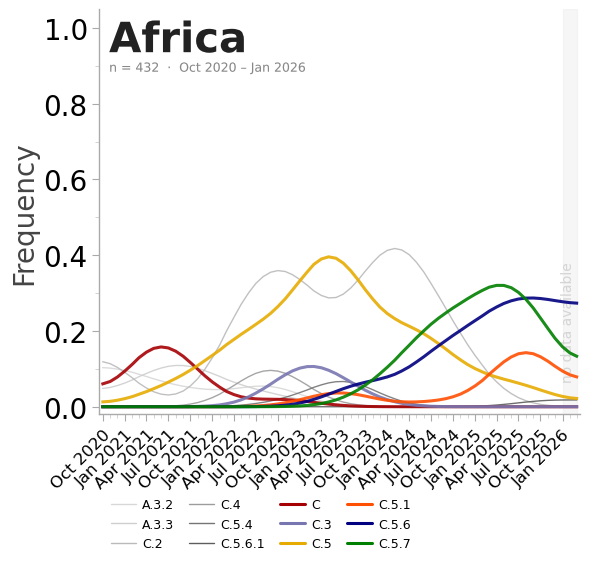

✓ Saved → ../figures/freq//subclade_freq_East_Asia.png


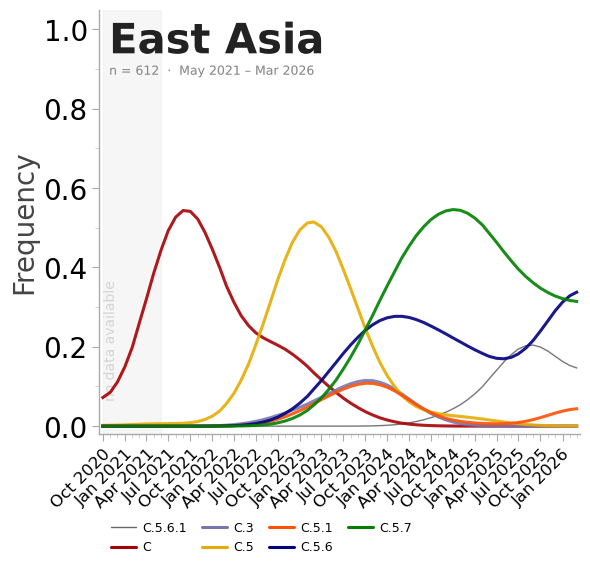

✓ Saved → ../figures/freq//subclade_freq_Europe.png


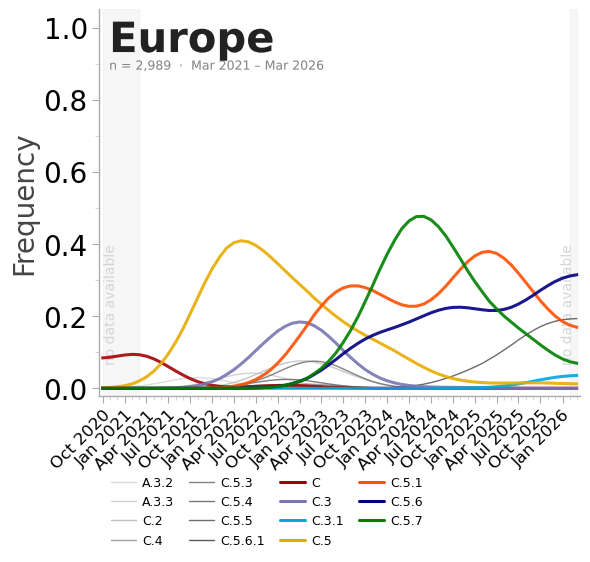

✓ Saved → ../figures/freq//subclade_freq_Japan_Korea.png


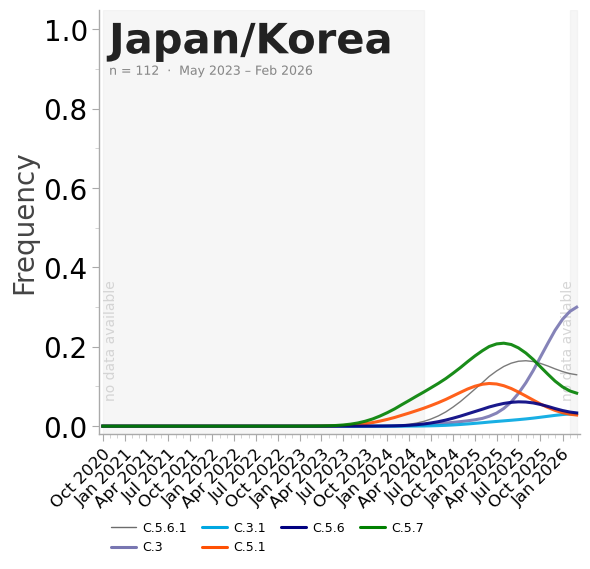

✓ Saved → ../figures/freq//subclade_freq_North_America.png


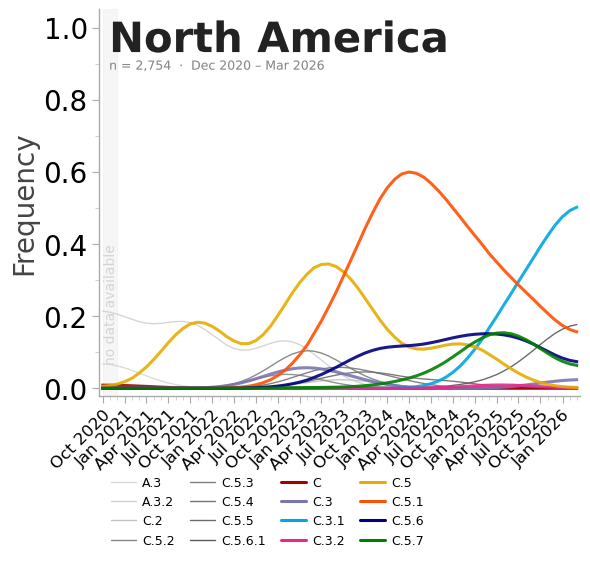

✓ Saved → ../figures/freq//subclade_freq_Oceania.png


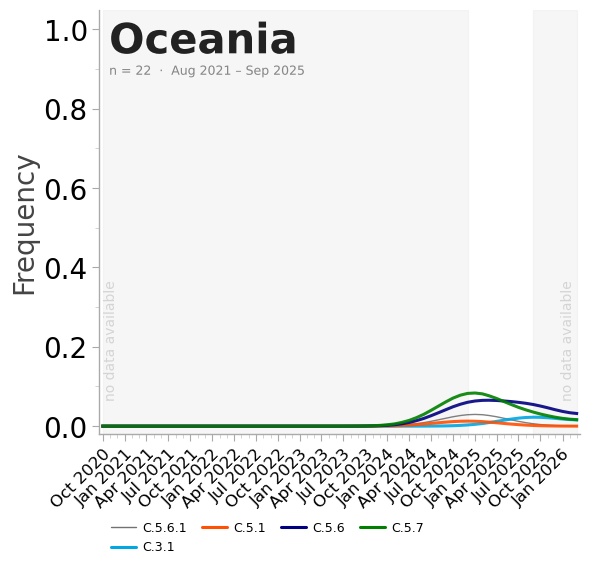

✓ Saved → ../figures/freq//subclade_freq_South_America.png


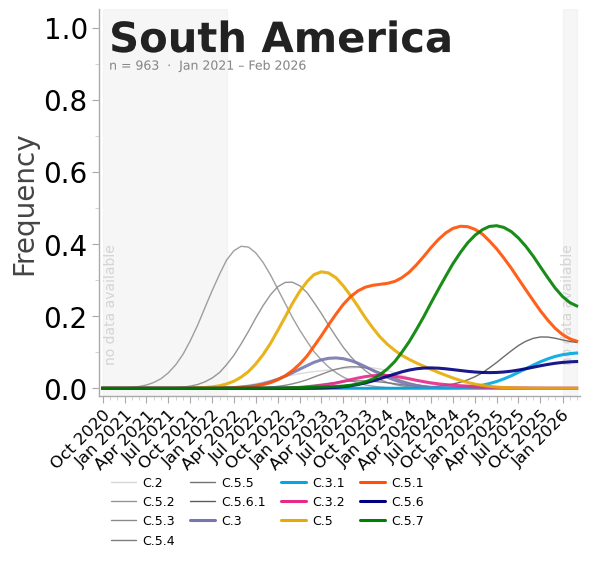

✓ Saved → ../figures/freq//subclade_freq_South_Asia.png


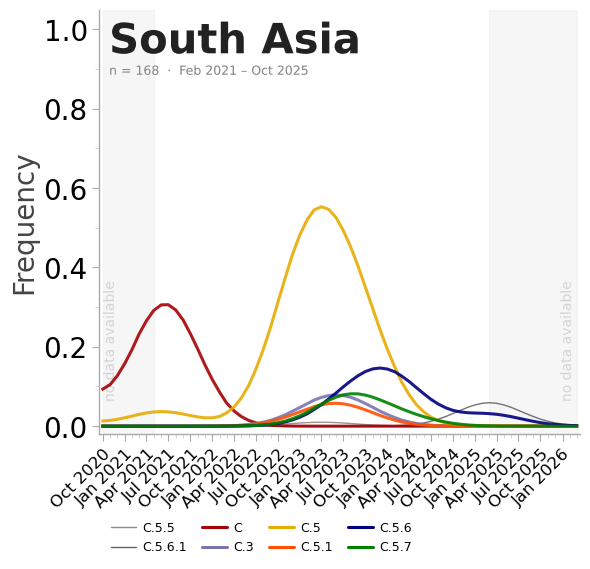

✓ Saved → ../figures/freq//subclade_freq_West_Asia.png


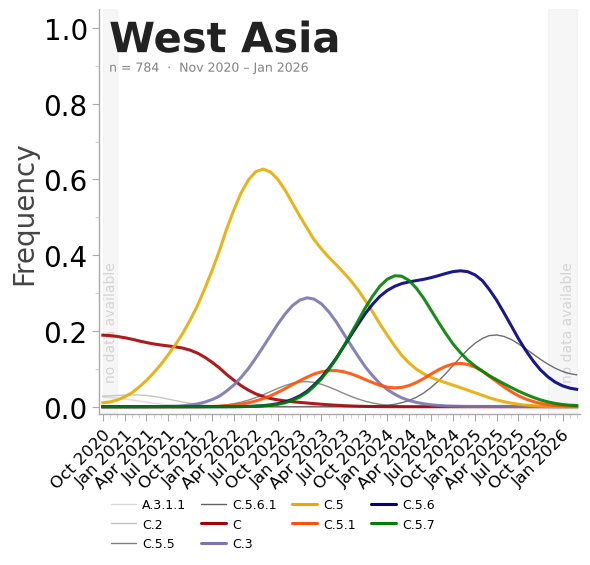

{'Africa': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>),
 'East Asia': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>),
 'Europe': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>),
 'Japan/Korea': (<Figure size 600x600 with 1 Axes>,
  <Axes: ylabel='Frequency'>),
 'North America': (<Figure size 600x600 with 1 Axes>,
  <Axes: ylabel='Frequency'>),
 'Oceania': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>),
 'South America': (<Figure size 600x600 with 1 Axes>,
  <Axes: ylabel='Frequency'>),
 'South Asia': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>),
 'West Asia': (<Figure size 600x600 with 1 Axes>, <Axes: ylabel='Frequency'>)}

In [35]:
# --- Single region with highlighted subclades ---
HIGHLIGHT = {
    "C.5.1":   "#d4c44a",
    "C.5.6":   "#e89320",
    "C.5.6.1": "#e05f18",
    "C.5.7":   "#cc2222",
    "C.3.1":   "#4a90d9",
}

HIGHLIGHT = {
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C": "#A50104" # vaccine
        }

# --- All regions at once, saving to a folder ---
plot_all_regions(
    df,
    color_dict   = HIGHLIGHT,
    show_grid=False,
    x_tick_fontsize  = 12,   # X-axis tick labels
    y_tick_fontsize  = 20,   # Y-axis tick labels
    x_label_fontsize = 20,   # X-axis label (if you add one)
    y_label_fontsize = 20,   # Y-axis label ("Frequency")
    title_fontsize   = 30,   # Plot title
    save_dir     = "../figures/freq/",
    figsize      = (6, 6),
    smooth_sigma = 4.5,
    min_month_n  = 3,
)